# NB01c — xBD and BRIGHT Transfer Learning Dataset Preparation

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.



| Field | Value |
|-------|-------|
| **Notebook** | `01c_xBD_BRIGHT_v8.ipynb` |
| **Version** | v8 |
| **Pipeline position** | Data preparation (parallel to NB01b). Feeds NB09d DL experiments. |
| **Last validated** | 2026-04-XX |

## Narrative

This notebook prepares two external building damage assessment datasets for transfer
learning in the deep learning experiments (NB09d). It runs independently from the
main BDA pipeline (NB01b-NB05) and produces standardized 64x64 tile datasets that
match the Sentinel-2 resolution of our pipeline.

**xBD** (Gupta et al. 2019, xView2 Challenge): VHR optical pre/post disaster image
pairs with JSON polygon labels across multiple disaster types. Only train + tier3
splits are usable (test/hold labels were never publicly released). This notebook
extracts, downsamples from 1024x1024 (0.3m) to 64x64 (~10m), rasterizes JSON polygon
labels to binary masks, and creates a stratified 80/20 train/val split.

**BRIGHT** (Chen et al. 2025, ESSD): Multimodal VHR dataset with pre-event optical
and post-event SAR imagery. Key advantage over xBD: labels are already raster masks
(no polygon rasterization needed) and it includes SAR post-event imagery for
SAR-aware transfer learning. Co-authored by Dietrich and Schindler (same group as
Dietrich 2025). Downloaded from Zenodo, downsampled to 64x64, split per official files.

Both datasets are downsampled to 64x64 to match the patch size used in the
Sentinel-based pipeline (NB05 patches). This enables transfer learning from VHR
to medium-resolution imagery in NB09d.

## Research Questions Addressed
- **RQ-DL:** Does xBD pretraining improve damage detection on Sentinel-resolution BDA data?
- **RQ-DL:** Does BRIGHT (with SAR) provide better transfer learning than xBD (optical only)?
- **RQ-DL:** Is combined xBD+BRIGHT pretraining superior to either alone?

## Scientific Rationale
Transfer learning from large labeled datasets to small domain-specific tasks is standard
in deep learning for remote sensing (Neumann et al. 2019). xBD is the largest public BDA
dataset but is optical-only. BRIGHT adds SAR modality which is critical for the pipeline
since SAR penetrates clouds and provides coherence/backscatter signals. The hypothesis is
that SAR-aware pretraining (BRIGHT) transfers better to the multimodal Sentinel pipeline
than optical-only pretraining (xBD).

Downsampling from VHR to 10m resolution follows the assumption that damage patterns
learned at fine scale (collapsed structures, debris fields) generalize to coarser
spectral signatures. This is validated if xBD-pretrained U-Net outperforms
random-initialized U-Net on BDA data (NB09d experiment D5 vs D7).

## Inputs

| Data | Source | Format | Size |
|------|--------|--------|------|
| xBD archives | xview2.org (pre-downloaded) | .tar.gz in `xBD_zip/` | ~20 GB |
| BRIGHT archives | Zenodo 10.5281/zenodo.15385983 | .zip (pre/post/target) | ~15-30 GB |

## Outputs

| Artifact | Path | Used by |
|----------|------|---------|
| xBD 64x64 images (train/val) | `XBD_OUTPUT_DIR/{split}/images/` | NB09d D1-D8 |
| xBD multi-class labels | `XBD_OUTPUT_DIR/{split}/labels/` | NB09d |
| xBD binary masks | `XBD_OUTPUT_DIR/{split}/binary_labels/` | NB09d |
| xBD split log | `XBD_OUTPUT_DIR/xbd_split_log.json` | NB09d |
| BRIGHT 64x64 pre-event (optical) | `BRIGHT_OUTPUT_DIR/{split}/pre-event/` | NB09d |
| BRIGHT 64x64 post-event (SAR) | `BRIGHT_OUTPUT_DIR/{split}/post-event/` | NB09d |
| BRIGHT 64x64 target masks | `BRIGHT_OUTPUT_DIR/{split}/target/` | NB09d |

## Prerequisites
- xBD archives manually downloaded from xview2.org to `xBD_zip/`
- Internet access for BRIGHT Zenodo download (Cell BRIGHT-DOWNLOAD)
- `pip install overturemaps rasterio opencv-python`

## Key Methodological Choices

| Choice | Justification | Reference |
|--------|---------------|-----------|
| 64x64 downsample target | Matches NB05 patch size and ~10m Sentinel resolution | Pipeline consistency |
| Bilinear for images, nearest for masks | Preserve class labels in masks | Standard practice |
| Binary: classes 2,3,4 -> 1 | Match UNOSAT binary protocol (damaged vs not) | Dietrich 2025 |
| Pre-mask: classes >= 1 -> 1 | Building footprint mask for pre-disaster | Gupta 2019 |
| Stratified split by damage presence | Prevent all-undamaged batches | Standard practice |
| xBD test/hold excluded | Labels never publicly released | xView2 competition rules |
| BRIGHT official splits | Reproducibility, event-based holdout | Chen et al. 2025 |

## Known Limitations
- xBD labels are JSON polygons — rasterization to 51x51/64x64 introduces discretization error
- xBD images were NOT georeferenced in public release (geotiff parts skipped)
- BRIGHT SAR is amplitude only (no phase/coherence), limiting transfer to our COH features
- Downsampling 0.3m to 10m loses fine-grained damage patterns (debris, cracks)
- xBD multi-disaster mix may not transfer well to conflict-specific urban damage

## Cell Structure

| Cell | ID | What | Dataset | Status |
|------|----|------|---------|--------|
| 0 | — | Documentation (this cell) | — | — |
| 1 | Cell 3 | Config (VERIFY_SHA1, EXTRACT flags) | Both | Config |
| 2 | Cell 4 | Load global_setup | Both | Config |
| 3 | — | xBD path setup | xBD | Config |
| 4-5 | Cell 19-EXTRACT | Extract xBD from tar.gz + SHA1 verify | xBD | **Core** |
| 6-7 | Cell 20 | Image properties analysis | xBD | Diagnostic |
| 8-9 | Cell 21 | Damage statistics analysis | xBD | Diagnostic |
| 10-11 | Cell 22 | Visualization with damage overlay | xBD | Diagnostic |
| 12-13 | Cell 19A | Downsample 1024->64 + rasterize JSON labels | xBD | **Core** |
| 14-15 | Cell 19B | Verify output + cleanup orphans | xBD | QA |
| 16-17 | Cell 19C | Stratified 80/20 train/val split | xBD | **Core** |
| 18-19 | Cell 19D | Binary mask generation (damaged vs not) | xBD | **Core** |
| 20 | — | BRIGHT dataset introduction (MD) | BRIGHT | — |
| 21-22 | BRIGHT-DOWNLOAD | Download from Zenodo | BRIGHT | **Core** |
| 23-24 | BRIGHT-EXTRACT | Extract zips | BRIGHT | **Core** |
| 25-26 | BRIGHT-PROPERTIES | Image properties analysis | BRIGHT | Diagnostic |
| 27-28 | BRIGHT-STATS | Damage statistics per event | BRIGHT | Diagnostic |
| 29-30 | BRIGHT-DOWNSAMPLE | Downsample 1024->64 | BRIGHT | **Core** |
| 31-32 | BRIGHT-VERIFY | Output verification | BRIGHT | QA |
| 33-34 | BRIGHT-SPLIT | Train/val/test split (official) | BRIGHT | **Core** |

## Thesis Mapping

| Thesis Section | Cells | Content |
|----------------|-------|---------|
| 3.2 Data Sources — Transfer Learning Datasets | 20-21, BRIGHT intro | xBD and BRIGHT description |
| 3.3 Preprocessing — Dataset Preparation | 19A, 19C, 19D, BRIGHT-DOWNSAMPLE, BRIGHT-SPLIT | Downsampling, splitting, mask generation |
| 4.x DL Results — Transfer Learning | All outputs | Referenced in NB09d experiments |
| Appendix | Cell 22 | xBD visualization examples |

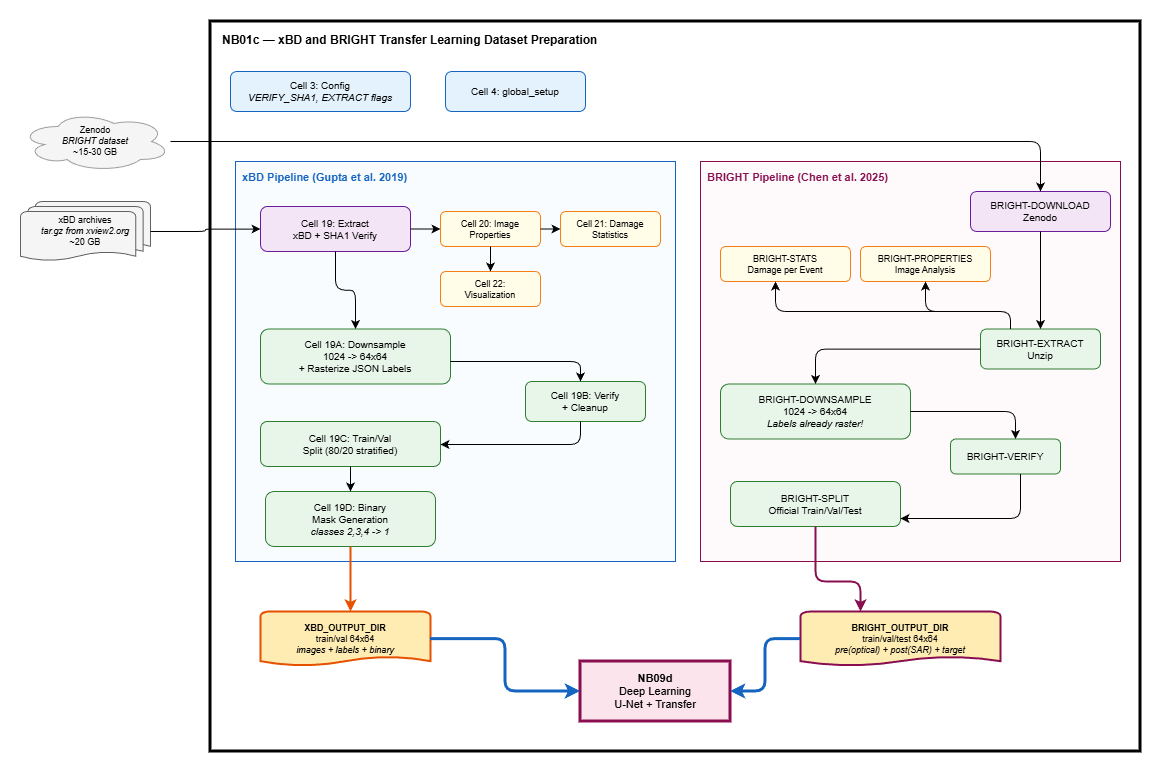

# CELL 4: COMPLETE ENVIRONMENT SETUP (BDA + SNAP12) - LOCAL WSL VERSION


In [1]:
# @title CELL 3: NB01c CONFIG
# ---- cell 4 (extraction) ----
VERIFY_SHA1 = True
EXTRACT_LABELED = True             # train + tier3 (have JSON labels)
EXTRACT_UNLABELED = False          # test + hold (images only, no labels)
EXTRACT_GEOTRANSFORMS = True
# ---- cell 6 (image properties) ----
N_SAMPLE_IMAGES = 20
# ---- cell 8 (damage stats) ----
N_SAMPLE_FILES = 1000
# ---- cell 10 (visualization) ----
N_SAMPLES = 5
# ---- cell 12 (downsampling) ----
SOURCE_IMAGE_SIZE = 1024
TARGET_SIZE = 64  # output patch size (matches BDA 64x64 grid)
NATIVE_10M_SIZE = 51  # 1024px * 0.5m / 10m = 51.2 -> intermediate 10m resolution
APPLY_ANTIALIASING = True
VERIFY_OUTPUTS = True
# ---- cell 16 (train/val split) ----
VAL_RATIO = 0.20
# ---- cell 18 (binary masks) ----
POST_THRESHOLD = 2                 # classes 2,3,4 -> 1 (damaged)
PRE_THRESHOLD = 1                  # class >= 1 -> 1 (building footprint

In [2]:
# @title CELL 4: LOAD GLOBAL SETUP
import platform, os
if platform.system() == 'Windows':
    _setup = r'F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py'
elif os.path.exists('/content/drive_f'):
    _setup = '/content/drive_f/masterthesis/notebooks/global_setup.py'
else:
    _setup = '/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py'
with open(_setup) as f:
    exec(f.read())

/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


BDA GLOBAL SETUP
Started: 2026-04-12 00:29:48
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------
  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /mnt/f/PROJECTS/masterthesis/data_stack OK

  TIER_SELECTION: [0, 1, 2]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: False
  CITIES_TO_PROCESS: 21 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------


<string>:535: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
----------------------------------------------------------------------
  GPT: Usage:
  Temporal baseline: 10-24 days
  Wavelength: 0.0555

[6/7] GPU Status
----------------------------------------------------------------------
  CUDA available: NVIDIA GeForce RTX 2070 SUPER
    CUDA version: 12.8

[7/7] Disk Space
----------------------------------------------------------------------
  GDrive (G:)     912.4/7452.0 GB (6539.7 GB free)
  GDrive (F:)     1170.5/3726.0 GB (2555.5 GB free)
  Local data      11333.9/14901.9 GB (3568.0 GB free)
  Data stack      1170.5/3726.0 GB (2555.5 GB free)
  WSL ext4        101.7/1006.9 GB (854.0 GB free)

GLOBAL SETUP COMPLETE
  Torch device: cuda
  Cities: 21, CITY=Avdiivka
  Functions: load_aoi(), load_aoi_gdf(), load_aoi

In [3]:
SPLIT_LOG_FILE = XBD_OUTPUT_DIR / "xbd_split_log.json"
final_train_img = XBD_OUTPUT_DIR / "train" / "images"
final_train_lbl = XBD_OUTPUT_DIR / "train" / "labels"
final_val_img = XBD_OUTPUT_DIR / "val" / "images"
final_val_lbl = XBD_OUTPUT_DIR / "val" / "labels"

# CELL 19-EXTRACT: xBD DATASET EXTRACTION

Extracts train + tier3 (labeled) from xBD_zip to xBD_original

SHA1 verification against xview2.org published hashes

In [4]:
# ====================================================
# CELL 19-EXTRACT: xBD DATASET EXTRACTION
# Extracts usable xBD data from downloaded archives
# Source: xBD_zip/ (downloaded tars from xview2.org)
# Target: xBD_original/ (extracted, ready for Cell 19A)
#
# Usable (have labels): train, tier3
# Images only (no public labels): test, hold
# Geotiff parts: SKIPPED (same images, 51GB, only adds georeferencing)
# ====================================================

import subprocess
import hashlib
import shutil
from pathlib import Path
from datetime import datetime

CELL_ID = "cell_19_extract"

# ==================== CONFIGURATION ====================
DRY_RUN = False
FORCE_RERUN = False        # True = re-extract even if already done

# SHA1 hashes from xview2.org download page
EXPECTED_SHA1 = {
    "train_images_labels_targets.tar": "b37a4ef4ee9c909e2b19d046e49d42ee3965714b",
    "tier3.tar": "5bf6aaf8a71980b633fb4661776a99a200891de5",
    "test_images_labels_targets.tar": "86ed3dba2f8d16ceceb75d451005054fefa9616f",
    "hold_images_labels_targets.tar": "fe7f162f0895bfaff134cab3abc23872f38d17da",
    "xview_geotransforms.json.tgz": "0b3bda08084ac102d8b540261ebbba0094203a2f",
}

print("=" * 80)
print("CELL 19-EXTRACT: xBD DATASET EXTRACTION")
print("=" * 80)
print(f"Source: {XBD_ZIP_DIR}")
print(f"Target: {XBD_ORIGINAL_DIR}")
print(f"DRY_RUN: {DRY_RUN}")
print(f"VERIFY_SHA1: {VERIFY_SHA1}")
print(f"EXTRACT_LABELED: {EXTRACT_LABELED}")
print(f"EXTRACT_UNLABELED: {EXTRACT_UNLABELED}")
print(f"EXTRACT_GEOTRANSFORMS: {EXTRACT_GEOTRANSFORMS}")

assert XBD_ZIP_DIR.exists(), f"Source not found: {XBD_ZIP_DIR}"
XBD_ORIGINAL_DIR.mkdir(parents=True, exist_ok=True)

# ==================== ALREADY-EXTRACTED CHECK ====================
def check_already_extracted(out_dir):
    """Check if labeled splits are already extracted with images and labels.
    Returns True if at least one split has images + labels.
    Checks for all expected labeled splits based on EXTRACT_LABELED config."""
    expected = []
    if EXTRACT_LABELED:
        expected.extend(["train", "tier3"])
    found = 0
    for split in expected:
        img_dir = out_dir / split / "images"
        lbl_dir = out_dir / split / "labels"
        if img_dir.exists() and lbl_dir.exists():
            if len(list(img_dir.glob("*.png"))) > 0 and len(list(lbl_dir.glob("*.json"))) > 0:
                found += 1
    return found == len(expected) and found > 0

if not FORCE_RERUN and check_already_extracted(XBD_ORIGINAL_DIR):
    print(f"\nALREADY EXTRACTED: {XBD_ORIGINAL_DIR}")
    print(f"  train/ and tier3/ found with images + labels")
    for item in sorted(XBD_ORIGINAL_DIR.iterdir()):
        if item.is_dir():
            n_imgs = sum(1 for _ in item.rglob("images/*.png"))
            n_lbls = sum(1 for _ in item.rglob("labels/*.json"))
            print(f"    {item.name}/: {n_imgs} images, {n_lbls} labels")
    print(f"\nSet FORCE_RERUN = True to re-extract.")
    print(f"\n{'='*80}")
    print(f"CELL 19-EXTRACT SKIPPED (already done)")
    print(f"{'='*80}")

else:
    start_time = datetime.now()

    # ==================== SHA1 VERIFICATION ====================
    def sha1_file(filepath):
        """Compute SHA1 hash of file, streaming to handle large files."""
        h = hashlib.sha1()
        with open(filepath, 'rb') as f:
            while True:
                chunk = f.read(64 * 1024 * 1024)  # 64MB chunks
                if not chunk:
                    break
                h.update(chunk)
        return h.hexdigest()

    # build list of files to process
    files_to_extract = []

    if EXTRACT_LABELED:
        files_to_extract.append(("train_images_labels_targets.tar", "train"))
        files_to_extract.append(("tier3.tar", "tier3"))

    if EXTRACT_UNLABELED:
        files_to_extract.append(("test_images_labels_targets.tar", "test"))
        files_to_extract.append(("hold_images_labels_targets.tar", "hold"))

    if EXTRACT_GEOTRANSFORMS:
        files_to_extract.append(("xview_geotransforms.json.tgz", "geotransforms"))

    # verify SHA1
    if VERIFY_SHA1:
        print(f"\n--- SHA1 VERIFICATION ---")
        all_ok = True
        for fname, label in files_to_extract:
            fpath = XBD_ZIP_DIR / fname
            if not fpath.exists():
                print(f"  MISSING: {fname}")
                all_ok = False
                continue
            print(f"  hashing {fname} ...", end="", flush=True)
            computed = sha1_file(fpath)
            expected = EXPECTED_SHA1.get(fname, "unknown")
            if computed == expected:
                print(f" OK")
            else:
                print(f" MISMATCH")
                print(f"    expected: {expected}")
                print(f"    computed: {computed}")
                all_ok = False

        if not all_ok:
            raise RuntimeError("SHA1 verification failed. Re-download corrupted files.")
        print("  All hashes verified.")

    # ==================== EXTRACTION ====================
    print(f"\n--- EXTRACTION ---")

    extracted = []

    for fname, label in files_to_extract:
        fpath = XBD_ZIP_DIR / fname
        if not fpath.exists():
            print(f"  SKIP: {fname} (not found)")
            continue

        # check if already extracted
        # tar files extract to a directory structure we need to discover
        # use --list to peek at top-level dir, or just extract to target
        size_gb = fpath.stat().st_size / 1e9
        print(f"\n  {fname} ({size_gb:.2f} GB) -> {label}")

        if DRY_RUN:
            print(f"    DRY_RUN: would extract")
            continue

        # extract to xBD_original
        # tar files from xview2 typically extract with a top-level directory
        # we extract to xBD_original and inspect afterward
        t0 = datetime.now()

        if fname.endswith('.tgz'):
            cmd = ["tar", "-xzf", str(fpath), "-C", str(XBD_ORIGINAL_DIR)]
        else:
            cmd = ["tar", "-xf", str(fpath), "-C", str(XBD_ORIGINAL_DIR)]

        print(f"    extracting...", flush=True)
        result = subprocess.run(cmd, capture_output=True, text=True)

        dt = (datetime.now() - t0).total_seconds()

        if result.returncode != 0:
            print(f"    ERROR (exit {result.returncode}): {result.stderr[:500]}")
        else:
            print(f"    done ({dt:.0f}s)")
            extracted.append(label)

    # ==================== POST-EXTRACTION INVENTORY ====================
    if not DRY_RUN:
        print(f"\n--- POST-EXTRACTION INVENTORY ---")
        print(f"  {XBD_ORIGINAL_DIR}")

        def count_dir(d):
            n_files = 0
            n_images = 0
            n_labels = 0
            total_bytes = 0
            for f in d.rglob('*'):
                if f.is_file():
                    n_files += 1
                    total_bytes += f.stat().st_size
                    if f.suffix == '.png':
                        n_images += 1
                    elif f.suffix == '.json' and f.parent.name == 'labels':
                        n_labels += 1
            return n_files, n_images, n_labels, total_bytes

        for item in sorted(XBD_ORIGINAL_DIR.iterdir()):
            if item.is_dir():
                n_files, n_images, n_labels, total_bytes = count_dir(item)
                has_labels_str = "LABELS" if n_labels > 0 else "images only"
                print(f"    {item.name}/: {n_files} files, {n_images} images, "
                      f"{n_labels} labels, {total_bytes / 1e9:.2f} GB [{has_labels_str}]")

                # show subdirs
                for sub in sorted(item.iterdir()):
                    if sub.is_dir():
                        n_sub = sum(1 for f in sub.rglob('*') if f.is_file())
                        print(f"      {sub.name}/: {n_sub} files")
            elif item.is_file():
                print(f"    {item.name}: {item.stat().st_size / 1e6:.1f} MB")

    # ==================== SUMMARY ====================
    duration = (datetime.now() - start_time).total_seconds()
    print(f"\n{'='*80}")
    print(f"CELL 19-EXTRACT COMPLETE")
    print(f"{'='*80}")
    print(f"Duration: {duration/60:.1f} minutes")
    print(f"Extracted: {', '.join(extracted) if extracted else 'nothing (DRY_RUN)'}")
    print(f"Target: {XBD_ORIGINAL_DIR}")
    print(f"{'='*80}")


CELL 19-EXTRACT: xBD DATASET EXTRACTION
Source: /content/masterthesis_local/xBD_zip
Target: /content/masterthesis_local/xBD_original
DRY_RUN: False
VERIFY_SHA1: True
EXTRACT_LABELED: True
EXTRACT_UNLABELED: False
EXTRACT_GEOTRANSFORMS: True

ALREADY EXTRACTED: /content/masterthesis_local/xBD_original
  train/ and tier3/ found with images + labels
    tier3/: 12738 images, 12738 labels
    train/: 5598 images, 5598 labels

Set FORCE_RERUN = True to re-extract.

CELL 19-EXTRACT SKIPPED (already done)


#  CELL 20: xBD IMAGE PROPERTIES ANALYSIS

In [5]:
# @title CELL 20: xBD IMAGE PROPERTIES ANALYSIS
# =============================================================================
# Auto-detects xBD directory structure, analyzes sample image properties
# (dimensions, channels, dtype, pixel stats), finds pre/post pairs,
# matches labels to pairs.
#
# Requires: Cell 19 (xBD extraction)
# =============================================================================

CELL_ID = "cell_20_xbd_images"
FORCE_RERUN = False

import json
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from datetime import datetime

# point at original extracted data (JSON labels + 1024x1024 images)
XBD_ROOT = XBD_SOURCE_DIR
CELL_LOG_FILE = LOGS_DIR / f"{CELL_ID}.json"

# ============================================================================
# DISCOVER LABELED SPLITS
# xBD public release: train + tier3 have labels, test + hold do NOT
# ============================================================================

def find_labeled_splits(xbd_root):
    """Find all subdirs under xbd_root that have both images/ and labels/."""
    labeled = {}
    if not xbd_root.exists():
        return labeled
    for item in sorted(xbd_root.iterdir()):
        if item.is_dir():
            has_imgs = (item / "images").exists() and len(list((item / "images").glob("*.png"))) > 0
            has_lbls = (item / "labels").exists() and len(list((item / "labels").glob("*.json"))) > 0
            if has_imgs and has_lbls:
                labeled[item.name] = item
    return labeled

LABELED_SPLITS = find_labeled_splits(XBD_ROOT)

if not LABELED_SPLITS:
    print("  WARNING: no labeled splits found in XBD_ROOT")
    print(f"  XBD_ROOT = {XBD_ROOT}")
else:
    for name, path in LABELED_SPLITS.items():
        n_img = len(list((path / "images").glob("*.png")))
        n_lbl = len(list((path / "labels").glob("*.json")))
        print(f"  {name}/: {n_img} images, {n_lbl} labels")

def find_image_pairs(image_dir):
    if not image_dir.exists():
        return {}
    pairs = {}
    for img_file in image_dir.glob('*.png'):
        name = img_file.stem
        if '_pre_disaster' in name:
            base = name.replace('_pre_disaster', '')
            post_file = img_file.parent / (name.replace('_pre_disaster', '_post_disaster') + '.png')
            if post_file.exists():
                pairs[base] = {'pre': img_file, 'post': post_file, 'base_name': base}
    return pairs

# ============================================================================
# CHECK IF ALREADY RUN
# ============================================================================

def check_cell_status():
    if CELL_LOG_FILE.exists() and not FORCE_RERUN:
        with open(CELL_LOG_FILE, 'r') as f:
            log = json.load(f)
        if log.get('status') == 'SUCCESS':
            return True, log
    return False, None

already_run, previous_log = check_cell_status()

if already_run:
    print(f"CELL 20 already run ({previous_log['timestamp'][:10]}). Set FORCE_RERUN=True to re-run.")
    if 'image_stats' in previous_log:
        s = previous_log['image_stats']
        print(f"  Size: {s.get('width_median',0):.0f}x{s.get('height_median',0):.0f}, "
              f"Channels: {s.get('channels','?')}, dtype: {s.get('dtype','?')}")
    print(f"  Pairs: {previous_log.get('image_pairs', '?'):,}")

else:
    # ========================================================================
    # MAIN EXECUTION
    # ========================================================================
    start_time = datetime.now()

    print("=" * 70)
    print("xBD IMAGE PROPERTIES ANALYSIS")
    print("=" * 70)

    # ========================================================================
    # PART 1: IMAGE PROPERTIES
    # ========================================================================

    if not LABELED_SPLITS:
        raise FileNotFoundError("No labeled splits found. Run Cell 19-EXTRACT first.")

    # sample images from all labeled splits
    image_files = []
    for split_dir in LABELED_SPLITS.values():
        image_files.extend(list((split_dir / "images").glob('*.png')))
    image_files = sorted(image_files)[:N_SAMPLE_IMAGES]
    print(f"\n--- PART 1: ANALYZING {len(image_files)} SAMPLE IMAGES ---")

    image_stats = []

    for idx, img_file in enumerate(image_files, 1):
        img = Image.open(img_file)
        img_array = np.array(img)

        stats = {
            'filename': img_file.name,
            'width': img.width,
            'height': img.height,
            'channels': img_array.shape[2] if len(img_array.shape) > 2 else 1,
            'dtype': str(img_array.dtype),
            'size_mb': img_file.stat().st_size / (1024**2),
            'mean': float(img_array.mean()),
            'std': float(img_array.std()),
            'min': int(img_array.min()),
            'max': int(img_array.max())
        }
        image_stats.append(stats)

        print(f"  [{idx}/{len(image_files)}] {img_file.name}: "
              f"{stats['width']}x{stats['height']}x{stats['channels']} "
              f"{stats['dtype']} [{stats['min']},{stats['max']}] "
              f"mean={stats['mean']:.1f} std={stats['std']:.1f} "
              f"{stats['size_mb']:.2f}MB")

    df_stats = pd.DataFrame(image_stats)

    print(f"\n  SUMMARY:")
    print(f"    Width:  {df_stats['width'].min()}-{df_stats['width'].max()} (median {df_stats['width'].median():.0f})")
    print(f"    Height: {df_stats['height'].min()}-{df_stats['height'].max()} (median {df_stats['height'].median():.0f})")
    print(f"    Channels: {df_stats['channels'].unique()}, dtype: {df_stats['dtype'].unique()}")
    print(f"    File size: {df_stats['size_mb'].min():.2f}-{df_stats['size_mb'].max():.2f} MB "
          f"(mean {df_stats['size_mb'].mean():.2f})")
    print(f"    Pixel mean: {df_stats['mean'].min():.1f}-{df_stats['mean'].max():.1f}, "
          f"std: {df_stats['std'].min():.1f}-{df_stats['std'].max():.1f}")

    # ========================================================================
    # PART 2: PRE/POST PAIRS
    # ========================================================================

    print(f"\n--- PART 2: PRE/POST IMAGE PAIRS ---")

    all_pairs = {}
    split_pair_counts = {}
    for split_name, split_dir in LABELED_SPLITS.items():
        pairs = find_image_pairs(split_dir / "images")
        split_pair_counts[split_name] = len(pairs)
        all_pairs.update(pairs)
        print(f"  {split_name}: {len(pairs):,} pairs")

    total_pairs = len(all_pairs)
    print(f"  Total: {total_pairs:,} pairs")

    if total_pairs > 0:
        print(f"\n  Sample pairs:")
        for idx, (base, _) in enumerate(list(all_pairs.items())[:5], 1):
            print(f"    {idx}. {base[:60]}")

    # ========================================================================
    # PART 3: MATCH LABELS
    # ========================================================================

    print(f"\n--- PART 3: LABEL MATCHING ---")

    pairs_with_labels = 0
    for split_name, split_dir in LABELED_SPLITS.items():
        lbl_dir = split_dir / "labels"
        if not lbl_dir.exists():
            continue
        for base, pair_data in all_pairs.items():
            if 'label' in pair_data:
                continue
            for suffix in ['_post_disaster', '_pre_disaster']:
                label_file = lbl_dir / (base + suffix + '.json')
                if label_file.exists():
                    pair_data['label'] = label_file
                    pairs_with_labels += 1
                    break

    coverage_pct = (pairs_with_labels / total_pairs * 100) if total_pairs > 0 else 0
    print(f"  Pairs with labels: {pairs_with_labels:,}/{total_pairs:,} ({coverage_pct:.1f}%)")

    # ========================================================================
    # LOG
    # ========================================================================

    duration = (datetime.now() - start_time).total_seconds()

    log_data = {
        'cell_id': CELL_ID,
        'status': 'SUCCESS',
        'timestamp': datetime.now().isoformat(),
        'duration_seconds': duration,
        'image_stats': {
            'n_analyzed': int(len(df_stats)),
            'width_min': int(df_stats['width'].min()),
            'width_max': int(df_stats['width'].max()),
            'width_median': float(df_stats['width'].median()),
            'height_min': int(df_stats['height'].min()),
            'height_max': int(df_stats['height'].max()),
            'height_median': float(df_stats['height'].median()),
            'channels': [int(x) for x in df_stats['channels'].unique()],
            'dtype': [str(x) for x in df_stats['dtype'].unique()],
            'size_mb_min': float(df_stats['size_mb'].min()),
            'size_mb_max': float(df_stats['size_mb'].max()),
            'size_mb_mean': float(df_stats['size_mb'].mean()),
            'pixel_mean_range': [float(df_stats['mean'].min()), float(df_stats['mean'].max())],
            'pixel_std_range': [float(df_stats['std'].min()), float(df_stats['std'].max())]
        },
        'image_pairs': int(total_pairs),
        'split_pair_counts': {k: int(v) for k, v in split_pair_counts.items()},
        
        'pairs_with_labels': int(pairs_with_labels),
        'label_coverage_pct': float(coverage_pct),
        'detected_splits': {k: str(v) for k, v in LABELED_SPLITS.items()}
    }
    with open(CELL_LOG_FILE, 'w') as f:
        json.dump(log_data, f, indent=2)

    print(f"\n{'='*70}")
    print(f"xBD IMAGE ANALYSIS COMPLETE ({duration:.1f}s)")
    print(f"  Analyzed: {len(df_stats)} images")
    print(f"  Pairs: {total_pairs:,} (labels: {pairs_with_labels:,})")
    print(f"{'='*70}")


  tier3/: 12738 images, 12738 labels
  train/: 5598 images, 5598 labels
CELL 20 already run (2026-03-14). Set FORCE_RERUN=True to re-run.
  Size: 1024x1024, Channels: [3], dtype: ['uint8']
  Pairs: 2,799


# CELL 21: xBD DAMAGE STATISTICS ANALYSIS

In [6]:
# @title CELL 21: xBD DAMAGE STATISTICS ANALYSIS
# =============================================================================
# Extracts damage classifications from xBD label JSONs, analyzes subtype
# distribution (no-damage, minor, major, destroyed), property keys,
# severity metrics. Creates damage distribution chart.
#
# Requires: Cell 19 (xBD extraction)
# =============================================================================

CELL_ID = "cell_21_xbd_statistics"
FORCE_RERUN = False

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from datetime import datetime

# point at original extracted data (JSON labels + 1024x1024 images)
XBD_ROOT = XBD_SOURCE_DIR
CELL_LOG_FILE = LOGS_DIR / f"{CELL_ID}.json"
CELL_IMAGE_DIR = Path(OUTPUTS_DIR) / CELL_ID
CELL_IMAGE_DIR.mkdir(exist_ok=True)

# ============================================================================
# DISCOVER LABELED SPLITS
# ============================================================================

def find_labeled_splits(xbd_root):
    """Find all subdirs under xbd_root that have both images/ and labels/."""
    labeled = {}
    if not xbd_root.exists():
        return labeled
    for item in sorted(xbd_root.iterdir()):
        if item.is_dir():
            has_imgs = (item / "images").exists() and len(list((item / "images").glob("*.png"))) > 0
            has_lbls = (item / "labels").exists() and len(list((item / "labels").glob("*.json"))) > 0
            if has_imgs and has_lbls:
                labeled[item.name] = item
    return labeled

LABELED_SPLITS = find_labeled_splits(XBD_ROOT)

if not LABELED_SPLITS:
    print("  WARNING: no labeled splits found in XBD_ROOT")
    print(f"  XBD_ROOT = {XBD_ROOT}")
else:
    for name, path in LABELED_SPLITS.items():
        n_img = len(list((path / "images").glob("*.png")))
        n_lbl = len(list((path / "labels").glob("*.json")))
        print(f"  {name}/: {n_img} images, {n_lbl} labels")

# ============================================================================
# HELPERS
# ============================================================================

def extract_damage_labels(label_dir, max_files=None):
    subtype_counts = Counter()
    damage_counts = Counter()
    all_properties = []
    files_processed = 0

    label_files = list(label_dir.glob('*_post_disaster.json'))
    if max_files:
        label_files = label_files[:max_files]

    total_files = len(label_files)
    print(f"  Processing {total_files:,} label files...")

    for idx, label_file in enumerate(label_files, 1):
        if idx % 100 == 0:
            print(f"    {idx:,}/{total_files:,} ({idx/total_files*100:.1f}%)", end='\r')
        try:
            with open(label_file, 'r') as f:
                data = json.load(f)

            if 'features' in data:
                features = data['features']
                features_list = []
                if isinstance(features, dict):
                    for coord_system, feature_list in features.items():
                        if isinstance(feature_list, list):
                            features_list.extend(feature_list)
                else:
                    features_list = features

                for feature in features_list:
                    if isinstance(feature, dict) and 'properties' in feature:
                        props = feature['properties']
                        all_properties.append(props)
                        if 'subtype' in props:
                            subtype_counts[props['subtype']] += 1
                        for key in ['damage', 'damaged', 'destruction']:
                            if key in props:
                                damage_counts[f"{key}:{props[key]}"] += 1

            files_processed += 1
        except Exception:
            continue

    print(f"\n  Processed {files_processed:,} files")
    return damage_counts, subtype_counts, all_properties, files_processed

# ============================================================================
# CHECK IF ALREADY RUN
# ============================================================================

def check_cell_status():
    if CELL_LOG_FILE.exists() and not FORCE_RERUN:
        with open(CELL_LOG_FILE, 'r') as f:
            log = json.load(f)
        if log.get('status') == 'SUCCESS':
            return True, log
    return False, None

already_run, previous_log = check_cell_status()

if already_run:
    print(f"CELL 21 already run ({previous_log['timestamp'][:10]}). Set FORCE_RERUN=True to re-run.")
    if 'damage_statistics' in previous_log:
        s = previous_log['damage_statistics']
        print(f"  Buildings: {s.get('total_buildings', 0):,}, Files: {s.get('files_analyzed', 0):,}")
        if 'damage_distribution' in s:
            for dt, count in s['damage_distribution'].items():
                pct = s['damage_percentages'].get(dt, 0)
                print(f"    {dt:20s}: {count:7,} ({pct:5.1f}%)")

else:
    # ========================================================================
    # MAIN EXECUTION
    # ========================================================================
    start_time = datetime.now()

    print("=" * 70)
    print("xBD DAMAGE STATISTICS ANALYSIS")
    print("=" * 70)

    if not LABELED_SPLITS:
        raise FileNotFoundError("No labeled splits found. Run Cell 19-EXTRACT first.")

    # ========================================================================
    # PART 1: EXTRACT DAMAGE LABELS (from all labeled splits)
    # ========================================================================

    print(f"\n--- PART 1: EXTRACTING DAMAGE CLASSIFICATIONS ---")

    damage_counts = Counter()
    subtype_counts = Counter()
    all_properties = []
    files_processed = 0

    for split_name, split_dir in LABELED_SPLITS.items():
        lbl_dir = split_dir / "labels"
        if not lbl_dir.exists():
            continue
        print(f"\n  Split: {split_name}")
        dc, sc, ap, fp = extract_damage_labels(lbl_dir, max_files=N_SAMPLE_FILES)
        damage_counts.update(dc)
        subtype_counts.update(sc)
        all_properties.extend(ap)
        files_processed += fp

    total_buildings = len(all_properties)
    print(f"  Total buildings: {total_buildings:,}")

    # ========================================================================
    # PART 2: DAMAGE DISTRIBUTION
    # ========================================================================

    print(f"\n--- PART 2: DAMAGE DISTRIBUTION ---")

    damage_percentages = {}
    if subtype_counts:
        for subtype, count in subtype_counts.most_common():
            pct = (count / total_buildings * 100) if total_buildings > 0 else 0
            damage_percentages[subtype] = pct
            print(f"  {subtype:30s}: {count:7,} ({pct:5.1f}%)")

        if 'no-damage' in subtype_counts:
            undamaged = subtype_counts['no-damage']
            damaged = total_buildings - undamaged
            print(f"\n  Undamaged: {undamaged:,} ({undamaged/total_buildings*100:.1f}%)")
            print(f"  Damaged:   {damaged:,} ({damaged/total_buildings*100:.1f}%)")

        if 'destroyed' in subtype_counts:
            destroyed = subtype_counts['destroyed']
            print(f"  Destroyed: {destroyed:,} ({destroyed/total_buildings*100:.1f}%)")
    else:
        print("  No damage subtype data found")

    # ========================================================================
    # PART 3: PROPERTY KEYS
    # ========================================================================

    print(f"\n--- PART 3: PROPERTY KEYS ---")

    all_keys = set()
    key_counts = Counter()
    if all_properties:
        for props in all_properties:
            for key in props.keys():
                all_keys.add(key)
                key_counts[key] += 1

        print(f"  {len(all_keys)} unique keys:")
        for key in sorted(all_keys):
            count = key_counts[key]
            pct = (count / len(all_properties) * 100)
            print(f"    {key:25s}: {count:7,} ({pct:5.1f}%)")

    # ========================================================================
    # PART 4: CHART
    # ========================================================================

    if len(subtype_counts) > 0:
        print(f"\n--- PART 4: CHART ---")

        fig, ax = plt.subplots(1, 1, figsize=(10, 6))

        damage_types = list(subtype_counts.keys())
        counts = list(subtype_counts.values())

        colors_map = {
            'no-damage': '#2ecc71', 'minor-damage': '#f1c40f',
            'major-damage': '#e67e22', 'destroyed': '#e74c3c',
            'un-classified': '#95a5a6'
        }
        bar_colors = [colors_map.get(dt, '#3498db') for dt in damage_types]

        bars = ax.bar(range(len(damage_types)), counts, color=bar_colors)
        ax.set_xticks(range(len(damage_types)))
        ax.set_xticklabels([dt.replace('-', '\n') for dt in damage_types], fontsize=11)
        ax.set_ylabel('Number of Buildings', fontsize=12)
        ax.set_title(f'xBD Building Damage Distribution (n={total_buildings:,})',
                    fontsize=14, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)

        for i, (dt, count) in enumerate(zip(damage_types, counts)):
            pct = (count / total_buildings * 100) if total_buildings > 0 else 0
            ax.text(i, count, f'{count:,}\n{pct:.1f}%',
                   ha='center', va='bottom', fontsize=10, fontweight='bold')

        plt.tight_layout()
        fig_path = CELL_IMAGE_DIR / "xbd_damage_distribution.png"
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        plt.close()
        print(f"  Saved: {fig_path}")

    # ========================================================================
    # LOG
    # ========================================================================

    duration = (datetime.now() - start_time).total_seconds()

    log_data = {
        'cell_id': CELL_ID,
        'status': 'SUCCESS',
        'timestamp': datetime.now().isoformat(),
        'duration_seconds': float(duration),
        'damage_statistics': {
            'total_buildings': int(total_buildings),
            'files_analyzed': int(files_processed),
            'damage_distribution': {k: int(v) for k, v in subtype_counts.items()},
            'damage_percentages': {k: float(v) for k, v in damage_percentages.items()},
            'property_keys': sorted(list(all_keys)) if all_properties else []
        },
    }
    with open(CELL_LOG_FILE, 'w') as f:
        json.dump(log_data, f, indent=2)

    print(f"\n{'='*70}")
    print(f"xBD DAMAGE STATISTICS COMPLETE ({duration:.1f}s)")
    print(f"  Buildings: {total_buildings:,}, Files: {files_processed:,}")
    print(f"  Damage types: {len(subtype_counts)}")
    print(f"{'='*70}")


  tier3/: 12738 images, 12738 labels
  train/: 5598 images, 5598 labels
CELL 21 already run (2026-03-14). Set FORCE_RERUN=True to re-run.
  Buildings: 99,610, Files: 1,000
    no-damage           :  45,004 ( 45.2%)
    minor-damage        :  21,748 ( 21.8%)
    destroyed           :   5,738 (  5.8%)
    major-damage        :  23,864 ( 24.0%)
    un-classified       :   3,256 (  3.3%)


# CELL 22: xBD IMAGE VISUALIZATION WITH DAMAGE ANNOTATIONS

In [7]:
# @title CELL 22: xBD IMAGE VISUALIZATION WITH DAMAGE ANNOTATIONS
# =============================================================================
# Finds pre/post image pairs with labels, draws damage polygons on images
# with color-coded overlay (no-damage=green, minor=yellow, major=orange,
# destroyed=red). Creates 2x2 comparison figures.
#
# Requires: Cell 19 (xBD extraction)
# =============================================================================

CELL_ID = "cell_22_xbd_visualization"
FORCE_RERUN = False

import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageDraw
from datetime import datetime
from shapely import wkt
import random

# point at original extracted data (JSON labels + 1024x1024 images)
XBD_ROOT = XBD_SOURCE_DIR
CELL_LOG_FILE = LOGS_DIR / f"{CELL_ID}.json"
CELL_IMAGE_DIR = Path(OUTPUTS_DIR) / CELL_ID
CELL_IMAGE_DIR.mkdir(exist_ok=True)

# ============================================================================
# DISCOVER LABELED SPLITS
# ============================================================================

def find_labeled_splits(xbd_root):
    """Find all subdirs under xbd_root that have both images/ and labels/."""
    labeled = {}
    if not xbd_root.exists():
        return labeled
    for item in sorted(xbd_root.iterdir()):
        if item.is_dir():
            has_imgs = (item / "images").exists() and len(list((item / "images").glob("*.png"))) > 0
            has_lbls = (item / "labels").exists() and len(list((item / "labels").glob("*.json"))) > 0
            if has_imgs and has_lbls:
                labeled[item.name] = item
    return labeled

LABELED_SPLITS = find_labeled_splits(XBD_ROOT)

if not LABELED_SPLITS:
    print("  WARNING: no labeled splits found in XBD_ROOT")
    print(f"  XBD_ROOT = {XBD_ROOT}")
else:
    for name, path in LABELED_SPLITS.items():
        n_img = len(list((path / "images").glob("*.png")))
        n_lbl = len(list((path / "labels").glob("*.json")))
        print(f"  {name}/: {n_img} images, {n_lbl} labels")

# ============================================================================
# HELPERS
# ============================================================================

DAMAGE_COLORS = {
    'no-damage': (46, 204, 113, 150),
    'minor-damage': (241, 196, 15, 150),
    'major-damage': (230, 126, 34, 150),
    'destroyed': (231, 76, 60, 200),
    'un-classified': (149, 165, 166, 100)
}

def find_image_pairs_with_labels(train_dir):
    pairs = []
    images_dir = train_dir / "images"
    labels_dir = train_dir / "labels"
    if not images_dir.exists() or not labels_dir.exists():
        return pairs
    for pre_img in images_dir.glob('*_pre_disaster.png'):
        base_name = pre_img.stem.replace('_pre_disaster', '')
        post_img = images_dir / f"{base_name}_post_disaster.png"
        label_post = labels_dir / f"{base_name}_post_disaster.json"
        label_pre = labels_dir / f"{base_name}_pre_disaster.json"
        if post_img.exists() and label_post.exists() and label_pre.exists():
            pairs.append({
                'base_name': base_name,
                'pre_image': pre_img,
                'post_image': post_img,
                'label_pre': label_pre,
                'label_post': label_post,
            })
    return pairs

def parse_wkt_to_polygon(wkt_string):
    try:
        return wkt.loads(wkt_string)
    except:
        return None

def draw_buildings_on_image(image_path, label_data, coord_system='xy'):
    img = Image.open(image_path).convert('RGBA')
    overlay = Image.new('RGBA', img.size, (255, 255, 255, 0))
    draw = ImageDraw.Draw(overlay)
    damage_counts = {'total': 0}

    if 'features' in label_data:
        features = label_data['features']
        features_list = []
        if isinstance(features, dict):
            if coord_system in features and isinstance(features[coord_system], list):
                features_list = features[coord_system]
        else:
            features_list = features

        for feature in features_list:
            if not isinstance(feature, dict):
                continue
            damage_type = 'un-classified'
            if 'properties' in feature:
                damage_type = feature['properties'].get('subtype', 'un-classified')
            damage_counts[damage_type] = damage_counts.get(damage_type, 0) + 1
            damage_counts['total'] += 1
            if 'wkt' in feature:
                poly = parse_wkt_to_polygon(feature['wkt'])
                if poly and poly.is_valid:
                    coords = list(poly.exterior.coords)
                    color = DAMAGE_COLORS.get(damage_type, (100, 100, 100, 100))
                    draw.polygon(coords, fill=color, outline=(0, 0, 0, 255))

    result = Image.alpha_composite(img, overlay)
    return result.convert('RGB'), damage_counts

# ============================================================================
# CHECK IF ALREADY RUN
# ============================================================================

def check_cell_status():
    if CELL_LOG_FILE.exists() and not FORCE_RERUN:
        with open(CELL_LOG_FILE, 'r') as f:
            log = json.load(f)
        if log.get('status') == 'SUCCESS':
            return True, log
    return False, None

already_run, previous_log = check_cell_status()

if already_run:
    print(f"CELL 22 already run ({previous_log['timestamp'][:10]}). Set FORCE_RERUN=True to re-run.")
    print(f"  Pairs: {previous_log.get('pairs_found', '?'):,}, "
          f"Visualizations: {previous_log.get('visualizations_created', '?')}")

else:
    # ========================================================================
    # MAIN EXECUTION
    # ========================================================================
    start_time = datetime.now()

    print("=" * 70)
    print("xBD IMAGE VISUALIZATION WITH DAMAGE ANNOTATIONS")
    print("=" * 70)

    if not LABELED_SPLITS:
        raise FileNotFoundError("No labeled splits found. Run Cell 19-EXTRACT first.")

    # ========================================================================
    # PART 1: FIND PAIRS
    # ========================================================================

    print(f"\n--- PART 1: FINDING IMAGE PAIRS ---")

    pairs = []
    for split_name, split_dir in LABELED_SPLITS.items():
        split_pairs = find_image_pairs_with_labels(split_dir)
        print(f"  {split_name}: {len(split_pairs):,} pairs with labels")
        pairs.extend(split_pairs)
    print(f"  Total: {len(pairs):,} pairs with labels")

    if len(pairs) > N_SAMPLES:
        sample_pairs = random.sample(pairs, N_SAMPLES)
    else:
        sample_pairs = pairs

    print(f"  Visualizing {len(sample_pairs)} pairs")

    # ========================================================================
    # PART 2: CREATE VISUALIZATIONS
    # ========================================================================

    print(f"\n--- PART 2: CREATING VISUALIZATIONS ---")

    visualizations_created = 0

    for idx, pair in enumerate(sample_pairs, 1):
        print(f"\n  [{idx}/{len(sample_pairs)}] {pair['base_name']}")

        try:
            with open(pair['label_pre'], 'r') as f:
                label_data_pre = json.load(f)
            with open(pair['label_post'], 'r') as f:
                label_data_post = json.load(f)

            pre_annotated, pre_counts = draw_buildings_on_image(
                pair['pre_image'], label_data_pre, coord_system='xy'
            )
            post_annotated, post_counts = draw_buildings_on_image(
                pair['post_image'], label_data_post, coord_system='xy'
            )

            pre_original = Image.open(pair['pre_image'])
            post_original = Image.open(pair['post_image'])

            fig, axes = plt.subplots(2, 2, figsize=(16, 16))

            axes[0, 0].imshow(pre_original)
            axes[0, 0].set_title('Pre-Disaster (Original)', fontsize=14, fontweight='bold')
            axes[0, 0].axis('off')

            axes[0, 1].imshow(pre_annotated)
            axes[0, 1].set_title(f'Pre-Disaster (Annotated)\n{pre_counts.get("total", 0)} buildings',
                                fontsize=14, fontweight='bold')
            axes[0, 1].axis('off')

            axes[1, 0].imshow(post_original)
            axes[1, 0].set_title('Post-Disaster (Original)', fontsize=14, fontweight='bold')
            axes[1, 0].axis('off')

            title_text = 'Post-Disaster (Annotated)\n'
            damage_summary = []
            for dt in ['no-damage', 'minor-damage', 'major-damage', 'destroyed']:
                if dt in post_counts:
                    damage_summary.append(f"{dt}: {post_counts[dt]}")
            if damage_summary:
                title_text += ' | '.join(damage_summary[:2]) + '\n'
                if len(damage_summary) > 2:
                    title_text += ' | '.join(damage_summary[2:])
            axes[1, 1].imshow(post_annotated)
            axes[1, 1].set_title(title_text, fontsize=12, fontweight='bold')
            axes[1, 1].axis('off')

            fig.suptitle(f'xBD Sample: {pair["base_name"]}',
                        fontsize=16, fontweight='bold', y=0.98)
            plt.tight_layout()

            fig_path = CELL_IMAGE_DIR / f"{pair['base_name']}.png"
            plt.savefig(fig_path, dpi=150, bbox_inches='tight')
            print(f"    Saved: {fig_path.name}")

            plt.show()
            visualizations_created += 1

        except Exception as e:
            print(f"    Failed: {e}")
            continue

    plt.close('all')

    # ========================================================================
    # LOG
    # ========================================================================

    duration = (datetime.now() - start_time).total_seconds()

    log_data = {
        'cell_id': CELL_ID,
        'status': 'SUCCESS',
        'timestamp': datetime.now().isoformat(),
        'duration_seconds': float(duration),
        'pairs_found': int(len(pairs)),
        'visualizations_created': int(visualizations_created),
        'output_directory': str(CELL_IMAGE_DIR),
    }
    with open(CELL_LOG_FILE, 'w') as f:
        json.dump(log_data, f, indent=2)

    print(f"\n{'='*70}")
    print(f"xBD VISUALIZATION COMPLETE ({duration:.1f}s)")
    print(f"  Pairs: {len(pairs):,}, Visualizations: {visualizations_created}")
    print(f"  Output: {CELL_IMAGE_DIR}")
    print(f"{'='*70}")


  tier3/: 12738 images, 12738 labels
  train/: 5598 images, 5598 labels
CELL 22 already run (2026-03-14). Set FORCE_RERUN=True to re-run.
  Pairs: 2,799, Visualizations: 5


# CELL 19A: xBD Dataset Downsampling for Sentinel-2 Resolution

In [8]:
# ====================================================
# CELL 19A: xBD Dataset Downsampling for Sentinel-2 Resolution
# Downsamples images to 64x64 (~8m/px over 512m ground coverage)
# Rasterizes JSON polygon labels to 64x64 multi-class masks
# Class map: 0=background, 1=no-damage, 2=minor, 3=major, 4=destroyed
# Processing unit: SAMPLE (stem = {disaster}_{id})
# Gate: post_disaster label must have buildings at 64x64
# If post is empty, entire sample (pre+post, images+labels) is skipped
# ====================================================

import json
import cv2
import numpy as np
from pathlib import Path
from datetime import datetime
import sys
import re
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ==================== CELL EXECUTION CONTROL ====================
CELL_ID = "cell_19a_xbd_downsampling"
FORCE_RERUN = True              # True = Re-process entire dataset

# xBD damage class mapping
DAMAGE_CLASS_MAP = {
    "no-damage": 1,
    "minor-damage": 2,
    "major-damage": 3,
    "destroyed": 4,
    "un-classified": 0
}



LOGS_DIR.mkdir(exist_ok=True, parents=True)
XBD_OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

CELL_LOG_FILE = LOGS_DIR / f"{CELL_ID}.json"
CELL_OUTPUT_LOG = LOGS_DIR / f"{CELL_ID}_output.log"

# ==================== LOGGING SETUP ====================
class Logger:
    def __init__(self, filepath):
        self.terminal = sys.stdout
        self.log = open(filepath, 'w', encoding='utf-8')

    def write(self, message):
        self.terminal.write(message)
        self.log.write(message)

    def flush(self):
        self.terminal.flush()
        self.log.flush()

    def close(self):
        self.log.close()

def debug_print(message, level="INFO"):
    timestamp = datetime.now().strftime("%H:%M:%S.%f")[:-3]
    print(f"[{timestamp}] [{level}] {message}")

def check_cell_status():
    if CELL_LOG_FILE.exists() and not FORCE_RERUN:
        with open(CELL_LOG_FILE, 'r') as f:
            log = json.load(f)
        if log.get('status') == 'SUCCESS':
            return True, log
    return False, None

# ==================== WKT POLYGON PARSER ====================
def parse_wkt_polygon(wkt_str):
    """Parse WKT POLYGON string into numpy array of coordinates.
    Returns array of shape (N, 2) with (x, y) pixel coords."""
    match = re.search(r'POLYGON\s*\(\((.*?)\)\)', wkt_str)
    if match is None:
        return None
    coord_str = match.group(1)
    coords = []
    for pair in coord_str.split(','):
        parts = pair.strip().split()
        if len(parts) == 2:
            coords.append([float(parts[0]), float(parts[1])])
    if len(coords) < 3:
        return None
    return np.array(coords, dtype=np.float64)

# ==================== RASTERIZE LABEL ====================
def rasterize_label_json(json_path, target_size, source_size):
    """Rasterize xBD JSON polygon labels: polygons at 10m native, then resize to target.
    Step 1: rasterize at NATIVE_10M_SIZE (51x51, 10m/px).
    Step 2: nearest-neighbor resize to target_size (64x64).
    This ensures mask pixels match the 10m information content of the images."""
    native_size = NATIVE_10M_SIZE
    mask_native = np.zeros((native_size, native_size), dtype=np.uint8)
    scale = native_size / source_size

    with open(json_path, 'r') as f:
        label_data = json.load(f)

    features = label_data.get("features", {}).get("xy", [])

    for feat in features:
        wkt = feat.get("wkt", "")
        props = feat.get("properties", {})
        damage_str = props.get("_damage", props.get("subtype", "un-classified"))
        damage_class = DAMAGE_CLASS_MAP.get(damage_str, 0)

        if damage_class == 0 and damage_str != "no-damage":
            continue

        coords = parse_wkt_polygon(wkt)
        if coords is None:
            continue

        # Scale from source to 10m native coordinate space
        coords_scaled = (coords * scale).astype(np.int32)
        coords_scaled = np.clip(coords_scaled, 0, native_size - 1)

        # fillPoly expects array of shape (N, 1, 2) as (x, y)
        pts = coords_scaled.reshape((-1, 1, 2))
        cv2.fillPoly(mask_native, [pts], int(damage_class))

    # resize 51 -> 64 with nearest neighbor (preserve class values)
    if native_size != target_size:
        mask = cv2.resize(mask_native, (target_size, target_size),
                          interpolation=cv2.INTER_NEAREST)
    else:
        mask = mask_native
    return mask

# ==================== DOWNSAMPLER ====================
class xBDDownsampler:
    def __init__(self, source_dir, output_dir, target_size, source_size):
        self.source_dir = Path(source_dir)
        self.output_dir = Path(output_dir)
        self.target_size = target_size
        self.source_size = source_size
        self.scale_factor = target_size / source_size
        self.effective_resolution = (source_size * 0.5) / target_size

        debug_print(f"Downsampling configuration:")
        debug_print(f"  Source size: {source_size}x{source_size} at ~0.5m/px")
        debug_print(f"  Native 10m size: {NATIVE_10M_SIZE}x{NATIVE_10M_SIZE} at 10.0m/px")
        debug_print(f"  Target size: {self.target_size}x{self.target_size}")
        debug_print(f"  Scale factor: {self.scale_factor:.4f}x")
        debug_print(f"  Effective resolution: 10.0m/px (forced to match Sentinel-2)")

    def downsample_image(self, img):
        """Two-step downsample: 1024 -> 51 (10m native) -> 64 (target frame).
        Step 1: area interpolation to 10m GSD (information-preserving downsample).
        Step 2: bilinear upsample to 64x64 (stretches to target patch size).
        Result: 64x64 image with 10m/px information content = matches Sentinel-2."""
        if APPLY_ANTIALIASING:
            sigma = 0.5 / (NATIVE_10M_SIZE / self.source_size)
            kernel_size = max(3, int(np.ceil(sigma * 3)) * 2 + 1)
            img = cv2.GaussianBlur(img, (kernel_size, kernel_size), sigma)

        # step 1: downsample to 10m native resolution
        native = cv2.resize(img, (NATIVE_10M_SIZE, NATIVE_10M_SIZE),
                            interpolation=cv2.INTER_AREA)
        # step 2: upsample to target patch size
        resampled = cv2.resize(native, (self.target_size, self.target_size),
                               interpolation=cv2.INTER_LINEAR)
        return resampled

    def process_all(self):
        """Sample-based processing of xBD dataset.
        A sample is defined by its stem: {disaster}_{id}.
        Gate: post_disaster label is rasterized first. If it has no buildings
        at 64x64 (all background), the entire sample is discarded.
        If post has buildings, all 4 files are written:
          images/{stem}_pre_disaster.png   (downsampled RGB)
          images/{stem}_post_disaster.png  (downsampled RGB)
          labels/{stem}_pre_disaster.png   (multi-class mask)
          labels/{stem}_post_disaster.png  (multi-class mask)
        """
        stats = {
            'samples_written': 0,
            'samples_skipped_empty': 0,
            'samples_failed': 0,
            'images_written': 0,
            'images_failed': 0,
            'labels_written': 0,
            'labels_failed': 0,
            'dirs_processed': []
        }

        # find all image directories
        image_dirs = sorted(self.source_dir.rglob('images'))
        image_dirs = [d for d in image_dirs if d.is_dir()]

        if not image_dirs:
            debug_print("No 'images' directories found in source", "ERROR")
            return stats

        debug_print(f"Found {len(image_dirs)} image directories")

        for img_dir in image_dirs:
            rel_path = img_dir.relative_to(self.source_dir)
            lbl_dir = img_dir.parent / 'labels'
            out_img_dir = self.output_dir / rel_path
            out_lbl_dir = self.output_dir / rel_path.parent / 'labels'
            out_img_dir.mkdir(parents=True, exist_ok=True)
            out_lbl_dir.mkdir(parents=True, exist_ok=True)

            dir_label = str(rel_path.parent)
            debug_print(f"Processing: {dir_label}")
            stats['dirs_processed'].append(dir_label)

            if not lbl_dir.exists():
                debug_print(f"No labels dir for {dir_label}, skipping entirely", "WARNING")
                continue

            # collect sample stems from post_disaster label JSONs
            post_jsons = sorted(lbl_dir.glob('*_post_disaster.json'))
            stems = [p.stem.replace('_post_disaster', '') for p in post_jsons]
            debug_print(f"  {len(stems)} samples (from post_disaster labels)")

            for stem in tqdm(stems, desc=f"Samples ({dir_label})"):
                try:
                    # --- GATE: rasterize post label first ---
                    post_json = lbl_dir / f"{stem}_post_disaster.json"
                    post_mask = rasterize_label_json(
                        post_json, self.target_size, self.source_size
                    )

                    if post_mask.max() == 0:
                        stats['samples_skipped_empty'] += 1
                        continue

                    # --- rasterize pre label ---
                    pre_json = lbl_dir / f"{stem}_pre_disaster.json"
                    if pre_json.exists():
                        pre_mask = rasterize_label_json(
                            pre_json, self.target_size, self.source_size
                        )
                    else:
                        debug_print(f"  Missing pre label: {stem}", "WARNING")
                        pre_mask = None

                    # --- downsample both images ---
                    pre_img_path = img_dir / f"{stem}_pre_disaster.png"
                    post_img_path = img_dir / f"{stem}_post_disaster.png"

                    pre_img = None
                    post_img = None

                    if post_img_path.exists():
                        raw = cv2.imread(str(post_img_path), cv2.IMREAD_UNCHANGED)
                        if raw is not None:
                            post_img = self.downsample_image(raw)

                    if pre_img_path.exists():
                        raw = cv2.imread(str(pre_img_path), cv2.IMREAD_UNCHANGED)
                        if raw is not None:
                            pre_img = self.downsample_image(raw)

                    if post_img is None:
                        debug_print(f"  Missing/unreadable post image: {stem}", "WARNING")
                        stats['samples_failed'] += 1
                        continue

                    # --- write all files for this sample ---
                    sample_ok = True

                    # post image (required)
                    if cv2.imwrite(str(out_img_dir / f"{stem}_post_disaster.png"), post_img):
                        stats['images_written'] += 1
                    else:
                        stats['images_failed'] += 1
                        sample_ok = False

                    # pre image (write if available)
                    if pre_img is not None:
                        if cv2.imwrite(str(out_img_dir / f"{stem}_pre_disaster.png"), pre_img):
                            stats['images_written'] += 1
                        else:
                            stats['images_failed'] += 1
                            sample_ok = False

                    # post label (required, already rasterized)
                    if cv2.imwrite(str(out_lbl_dir / f"{stem}_post_disaster.png"), post_mask):
                        stats['labels_written'] += 1
                    else:
                        stats['labels_failed'] += 1
                        sample_ok = False

                    # pre label (write if available)
                    if pre_mask is not None:
                        if cv2.imwrite(str(out_lbl_dir / f"{stem}_pre_disaster.png"), pre_mask):
                            stats['labels_written'] += 1
                        else:
                            stats['labels_failed'] += 1
                            sample_ok = False

                    if sample_ok:
                        stats['samples_written'] += 1
                    else:
                        stats['samples_failed'] += 1

                except Exception as e:
                    debug_print(f"Error processing sample {stem}: {e}", "ERROR")
                    stats['samples_failed'] += 1

        return stats

    def verify_output(self):
        """Verify downsampled dataset integrity.
        Checks that every sample has matched pre+post images and labels."""
        debug_print("Verifying output integrity...")

        verification = {
            'total_images': 0,
            'total_labels': 0,
            'total_samples': 0,
            'complete_samples': 0,
            'incomplete_samples': [],
            'dimension_errors': 0,
            'class_distribution': {str(k): 0 for k in range(5)},
            'all_valid': True
        }

        out_image_dirs = sorted(self.output_dir.rglob('images'))
        out_image_dirs = [d for d in out_image_dirs if d.is_dir()]

        for img_dir in out_image_dirs:
            lbl_dir = img_dir.parent / 'labels'

            # count files
            img_files = sorted(img_dir.glob('*.png'))
            lbl_files = sorted(lbl_dir.glob('*.png')) if lbl_dir.exists() else []
            verification['total_images'] += len(img_files)
            verification['total_labels'] += len(lbl_files)

            # collect sample stems from post images
            post_stems = set()
            for f in img_files:
                if '_post_disaster' in f.stem:
                    post_stems.add(f.stem.replace('_post_disaster', ''))

            verification['total_samples'] += len(post_stems)

            for stem in post_stems:
                has_pre_img = (img_dir / f"{stem}_pre_disaster.png").exists()
                has_post_img = (img_dir / f"{stem}_post_disaster.png").exists()
                has_pre_lbl = lbl_dir.exists() and (lbl_dir / f"{stem}_pre_disaster.png").exists()
                has_post_lbl = lbl_dir.exists() and (lbl_dir / f"{stem}_post_disaster.png").exists()

                if has_pre_img and has_post_img and has_pre_lbl and has_post_lbl:
                    verification['complete_samples'] += 1
                else:
                    missing = []
                    if not has_pre_img: missing.append('pre_img')
                    if not has_post_img: missing.append('post_img')
                    if not has_pre_lbl: missing.append('pre_lbl')
                    if not has_post_lbl: missing.append('post_lbl')
                    if len(verification['incomplete_samples']) < 10:
                        verification['incomplete_samples'].append(
                            {'stem': stem, 'missing': missing}
                        )

            # sample class distribution from first 50 post labels
            checked = 0
            if lbl_dir.exists():
                for f in sorted(lbl_dir.glob('*_post_disaster.png')):
                    if checked >= 50:
                        break
                    mask = cv2.imread(str(f), cv2.IMREAD_UNCHANGED)
                    if mask is not None:
                        h, w = mask.shape[:2]
                        if h != self.target_size or w != self.target_size:
                            verification['dimension_errors'] += 1
                            verification['all_valid'] = False
                        for cls_val in range(5):
                            verification['class_distribution'][str(cls_val)] += int(np.sum(mask == cls_val))
                    checked += 1

        if verification['incomplete_samples']:
            verification['all_valid'] = False

        return verification

# ==================== MAIN EXECUTION ====================
already_run, previous_log = check_cell_status()

if already_run:
    print("=" * 80)
    print(f"CELL ALREADY RUN SUCCESSFULLY")
    print("=" * 80)
    print(f"Last run: {previous_log['timestamp']}")
    print(f"Duration: {previous_log.get('duration_seconds', 0)/60:.2f} minutes")
    print(f"Output: {XBD_OUTPUT_DIR}")
    print(f"\nSet FORCE_RERUN = True to re-execute")

    if CELL_OUTPUT_LOG.exists():
        print("\n" + "=" * 80)
        print("PREVIOUS OUTPUT (last 30 lines):")
        print("=" * 80)
        with open(CELL_OUTPUT_LOG, 'r') as f:
            lines = f.readlines()
            print(''.join(lines[-30:]))

else:
    start_time = datetime.now()
    logger = Logger(CELL_OUTPUT_LOG)
    sys.stdout = logger

    try:
        print("=" * 80)
        print("CELL 19A: xBD Dataset Downsampling + Label Rasterization")
        print("=" * 80)
        print(f"FORCE_RERUN: {FORCE_RERUN}")
        print(f"VERIFY_OUTPUTS: {VERIFY_OUTPUTS}")
        print(f"Target size: {TARGET_SIZE}x{TARGET_SIZE}")
        print(f"Antialiasing: {APPLY_ANTIALIASING}")
        print(f"Processing unit: SAMPLE (gate on post_disaster label)")
        print(f"Started: {start_time.isoformat()}")
        print()

        if not XBD_SOURCE_DIR.exists():
            raise FileNotFoundError(f"xBD source directory not found: {XBD_SOURCE_DIR}")

        debug_print(f"Source: {XBD_SOURCE_DIR}")
        debug_print(f"Output: {XBD_OUTPUT_DIR}")

        # Initialize downsampler
        downsampler = xBDDownsampler(
            source_dir=XBD_SOURCE_DIR,
            output_dir=XBD_OUTPUT_DIR,
            target_size=TARGET_SIZE,
            source_size=SOURCE_IMAGE_SIZE
        )

        # Process everything
        stats = downsampler.process_all()

        print("\n" + "=" * 80)
        print("PROCESSING SUMMARY")
        print("=" * 80)
        print(f"Directories processed: {len(stats['dirs_processed'])}")
        for d in stats['dirs_processed']:
            print(f"  {d}")
        print(f"Samples: {stats['samples_written']} written, "
              f"{stats['samples_skipped_empty']} skipped (empty at 64x64), "
              f"{stats['samples_failed']} failed")
        print(f"Images: {stats['images_written']} written, {stats['images_failed']} failed")
        print(f"Labels: {stats['labels_written']} written, {stats['labels_failed']} failed")
        total_samples = stats['samples_written'] + stats['samples_skipped_empty'] + stats['samples_failed']
        if total_samples > 0:
            pct = 100 * stats['samples_written'] / total_samples
            print(f"  ({pct:.1f}% of samples have buildings at {TARGET_SIZE}x{TARGET_SIZE})")

        # Verify outputs
        verification = None
        if VERIFY_OUTPUTS:
            print("\n" + "=" * 80)
            print("VERIFYING OUTPUT INTEGRITY")
            print("=" * 80)
            verification = downsampler.verify_output()
            print(f"Total output images: {verification['total_images']}")
            print(f"Total output labels: {verification['total_labels']}")
            print(f"Total samples:       {verification['total_samples']}")
            print(f"Complete (4 files):  {verification['complete_samples']}")
            if verification['incomplete_samples']:
                print(f"Incomplete samples (first 10):")
                for s in verification['incomplete_samples']:
                    print(f"  {s['stem']}: missing {s['missing']}")
            print(f"Dimension errors:    {verification['dimension_errors']}")
            print(f"Sample class distribution (first 50 post masks, pixel counts):")
            for cls, count in verification['class_distribution'].items():
                cls_name = {0: 'background', 1: 'no-damage', 2: 'minor', 3: 'major', 4: 'destroyed'}.get(int(cls), cls)
                print(f"  {cls} ({cls_name}): {count}")
            if verification['all_valid']:
                print("\nAll outputs valid")
            else:
                print("\nSome outputs have issues (see above)")

        end_time = datetime.now()
        duration = (end_time - start_time).total_seconds()

        log_data = {
            'cell_id': CELL_ID,
            'status': 'SUCCESS',
            'timestamp': end_time.isoformat(),
            'duration_seconds': duration,
            'configuration': {
                'source_size': SOURCE_IMAGE_SIZE,
                'target_size': TARGET_SIZE,
                'scale_factor': TARGET_SIZE / SOURCE_IMAGE_SIZE,
                'effective_resolution_m': (SOURCE_IMAGE_SIZE * 0.5) / TARGET_SIZE,
                'antialiasing': APPLY_ANTIALIASING,
                'damage_class_map': DAMAGE_CLASS_MAP,
                'processing_unit': 'sample',
                'gate': 'post_disaster label must have buildings'
            },
            'paths': {
                'source': str(XBD_SOURCE_DIR),
                'output': str(XBD_OUTPUT_DIR)
            },
            'statistics': stats,
            'verification': verification,
            'flags': {
                'force_rerun': FORCE_RERUN,
                'verify_outputs': VERIFY_OUTPUTS
            }
        }

        with open(CELL_LOG_FILE, 'w') as f:
            json.dump(log_data, f, indent=2)

        print("\n" + "=" * 80)
        print("CELL 19A COMPLETE")
        print("=" * 80)
        print(f"Duration: {duration/60:.2f} minutes")
        print(f"Samples: {stats['samples_written']} (complete, 4 files each)")
        print(f"Skipped: {stats['samples_skipped_empty']} (no buildings at 64x64)")
        print(f"Failed:  {stats['samples_failed']}")
        print(f"\nLog saved to: {CELL_LOG_FILE}")
        print(f"Dataset saved to: {XBD_OUTPUT_DIR}")

    except Exception as e:
        end_time = datetime.now()
        duration = (end_time - start_time).total_seconds()

        log_data = {
            'cell_id': CELL_ID,
            'status': 'FAILED',
            'timestamp': end_time.isoformat(),
            'duration_seconds': duration,
            'error': str(e),
            'error_type': type(e).__name__
        }

        with open(CELL_LOG_FILE, 'w') as f:
            json.dump(log_data, f, indent=2)

        print(f"\nCell Failed: {e}")
        debug_print(f"FATAL ERROR: {type(e).__name__} - {e}", "ERROR")
        import traceback
        traceback.print_exc()
        raise

    finally:
        sys.stdout = logger.terminal
        logger.close()

print(f"\n{'='*80}")
print(f"CELL 19A EXECUTION COMPLETE")
print(f"{'='*80}")


CELL 19A: xBD Dataset Downsampling + Label Rasterization
FORCE_RERUN: True
VERIFY_OUTPUTS: True
Target size: 64x64
Antialiasing: True
Processing unit: SAMPLE (gate on post_disaster label)
Started: 2026-04-12T00:30:49.446590

[00:30:49.450] [INFO] Source: /content/masterthesis_local/xBD_original
[00:30:49.450] [INFO] Output: /content/drive_f/masterthesis/data/xBD_64
[00:30:49.450] [INFO] Downsampling configuration:
[00:30:49.450] [INFO]   Source size: 1024x1024 at ~0.5m/px
[00:30:49.450] [INFO]   Native 10m size: 51x51 at 10.0m/px
[00:30:49.450] [INFO]   Target size: 64x64
[00:30:49.450] [INFO]   Scale factor: 0.0625x
[00:30:49.450] [INFO]   Effective resolution: 10.0m/px (forced to match Sentinel-2)
[00:30:49.759] [INFO] Found 2 image directories
[00:30:49.764] [INFO] Processing: tier3
[00:30:49.342] [INFO]   6369 samples (from post_disaster labels)


Samples (tier3): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6369/6369 [34:12<00:00,  3.10it/s]


[01:05:01.696] [INFO] Processing: train
[01:05:01.837] [INFO]   2799 samples (from post_disaster labels)


Samples (train): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2799/2799 [33:48<00:00,  1.38it/s]



PROCESSING SUMMARY
Directories processed: 2
  tier3
  train
Samples: 5494 written, 3674 skipped (empty at 64x64), 0 failed
Images: 10988 written, 0 failed
Labels: 10988 written, 0 failed
  (59.9% of samples have buildings at 64x64)

VERIFYING OUTPUT INTEGRITY
[01:38:50.059] [INFO] Verifying output integrity...
Total output images: 18325
Total output labels: 18326
Total samples:       9163
Complete (4 files):  9162
Incomplete samples (first 10):
  hurricane-florence_00000361: missing ['pre_img']
Dimension errors:    0
Sample class distribution (first 50 post masks, pixel counts):
  0 (background): 546322
  1 (no-damage): 46366
  2 (minor): 10433
  3 (major): 5130
  4 (destroyed): 6149

Some outputs have issues (see above)

CELL 19A COMPLETE
Duration: 70.39 minutes
Samples: 5494 (complete, 4 files each)
Skipped: 3674 (no buildings at 64x64)
Failed:  0

Log saved to: /content/drive_f/masterthesis/data/logs/cell_19a_xbd_downsampling.json
Dataset saved to: /content/drive_f/masterthesis/dat

# CELL 19B: xBD OUTPUT VERIFICATION + CLEANUP
Verifies Cell 19A output, removes orphan images as safety net

Does NOT touch xBD_original source

In [9]:
# ====================================================
# CELL 19B: xBD OUTPUT VERIFICATION + CLEANUP
# Verifies Cell 19A output integrity
# Removes orphan images (images without matching labels) as safety net
# Does NOT touch xBD_original source
# ====================================================

import shutil
from pathlib import Path
from datetime import datetime

CELL_ID = "cell_19b_xbd_cleanup"
DRY_RUN = False   # True = show what would be deleted, False = actually delete

print("=" * 80)
print("CELL 19B: xBD OUTPUT VERIFICATION + CLEANUP")
print("=" * 80)
print(f"DRY_RUN: {DRY_RUN}")
print(f"Output dir: {XBD_OUTPUT_DIR}")
print()

if not XBD_OUTPUT_DIR.exists():
    raise FileNotFoundError(f"Output directory does not exist: {XBD_OUTPUT_DIR}. Run Cell 19A first.")

bytes_freed = 0

# ---- 1. Inventory source (read-only, just report) ----
print("--- Source xBD_original (read-only inventory) ---")
if XBD_SOURCE_DIR.exists():
    for item in sorted(XBD_SOURCE_DIR.iterdir()):
        if item.is_dir():
            n_imgs = len(list(item.rglob('images/*.png')))
            n_lbls = len(list(item.rglob('labels/*.json')))
            has_lbl = "LABELS" if n_lbls > 0 else "no labels"
            print(f"  {item.name}/: {n_imgs} images, {n_lbls} label JSONs [{has_lbl}]")
else:
    print(f"  not found: {XBD_SOURCE_DIR}")

# ---- 2. Inventory output ----
print(f"\n--- Output xBD_64 ---")
for item in sorted(XBD_OUTPUT_DIR.iterdir()):
    if item.is_dir():
        img_dir = item / "images"
        lbl_dir = item / "labels"
        n_imgs = len(list(img_dir.glob("*.png"))) if img_dir.exists() else 0
        n_lbls = len(list(lbl_dir.glob("*.png"))) if lbl_dir.exists() else 0
        print(f"  {item.name}/: {n_imgs} images, {n_lbls} label masks")

# ---- 3. Orphan cleanup per split ----
print(f"\n--- Orphan check (images without matching post label) ---")
for split_dir in sorted(XBD_OUTPUT_DIR.iterdir()):
    if not split_dir.is_dir():
        continue

    img_dir = split_dir / "images"
    lbl_dir = split_dir / "labels"

    if not img_dir.exists() or not lbl_dir.exists():
        continue

    # a sample is valid if its post_disaster label exists
    valid_stems = set()
    for lf in lbl_dir.glob("*_post_disaster.png"):
        valid_stems.add(lf.stem.replace("_post_disaster", ""))

    orphan_count = 0
    orphan_bytes = 0

    for img_path in sorted(img_dir.glob("*.png")):
        # extract stem
        stem = img_path.stem
        for suffix in ["_pre_disaster", "_post_disaster"]:
            stem = stem.replace(suffix, "")

        if stem not in valid_stems:
            orphan_count += 1
            orphan_bytes += img_path.stat().st_size
            if not DRY_RUN:
                img_path.unlink()

    # also check orphan pre labels (pre label exists but no post label)
    orphan_lbl_count = 0
    for lf in sorted(lbl_dir.glob("*_pre_disaster.png")):
        stem = lf.stem.replace("_pre_disaster", "")
        if stem not in valid_stems:
            orphan_lbl_count += 1
            orphan_bytes += lf.stat().st_size
            if not DRY_RUN:
                lf.unlink()

    action = "would delete" if DRY_RUN else "deleted"
    print(f"  {split_dir.name}/: {orphan_count} orphan images, "
          f"{orphan_lbl_count} orphan labels, "
          f"{orphan_bytes / 1e6:.1f} MB ({action})")
    bytes_freed += orphan_bytes

# ---- 4. Sample completeness check ----
print(f"\n--- Sample completeness (4 files per sample) ---")
for split_dir in sorted(XBD_OUTPUT_DIR.iterdir()):
    if not split_dir.is_dir():
        continue

    img_dir = split_dir / "images"
    lbl_dir = split_dir / "labels"

    if not img_dir.exists() or not lbl_dir.exists():
        continue

    post_lbl_stems = set()
    for lf in lbl_dir.glob("*_post_disaster.png"):
        post_lbl_stems.add(lf.stem.replace("_post_disaster", ""))

    complete = 0
    incomplete = 0
    incomplete_examples = []

    for stem in sorted(post_lbl_stems):
        has_pre_img = (img_dir / f"{stem}_pre_disaster.png").exists()
        has_post_img = (img_dir / f"{stem}_post_disaster.png").exists()
        has_pre_lbl = (lbl_dir / f"{stem}_pre_disaster.png").exists()
        has_post_lbl = True  # gate condition

        if has_pre_img and has_post_img and has_pre_lbl:
            complete += 1
        else:
            incomplete += 1
            if len(incomplete_examples) < 5:
                missing = []
                if not has_pre_img: missing.append("pre_img")
                if not has_post_img: missing.append("post_img")
                if not has_pre_lbl: missing.append("pre_lbl")
                incomplete_examples.append(f"{stem}: {missing}")

    print(f"  {split_dir.name}/: {complete} complete, {incomplete} incomplete")
    for ex in incomplete_examples:
        print(f"    {ex}")

# ---- Summary ----
print(f"\n{'='*80}")
print(f"CLEANUP SUMMARY")
print(f"{'='*80}")
if DRY_RUN:
    print(f"DRY_RUN: would free {bytes_freed / 1e6:.1f} MB")
    print(f"Set DRY_RUN = False to delete orphans.")
else:
    print(f"Freed: {bytes_freed / 1e6:.1f} MB")
print(f"\n{'='*80}")
print(f"CELL 19B COMPLETE")
print(f"{'='*80}")


CELL 19B: xBD OUTPUT VERIFICATION + CLEANUP
DRY_RUN: False
Output dir: /content/drive_f/masterthesis/data/xBD_64

--- Source xBD_original (read-only inventory) ---
  tier3/: 12738 images, 12738 label JSONs [LABELS]
  train/: 5598 images, 5598 label JSONs [LABELS]

--- Output xBD_64 ---
  tier3/: 6506 images, 6506 label masks
  train/: 9698 images, 9698 label masks
  val/: 2121 images, 2122 label masks

--- Orphan check (images without matching post label) ---
  tier3/: 0 orphan images, 0 orphan labels, 0.0 MB (deleted)
  train/: 0 orphan images, 0 orphan labels, 0.0 MB (deleted)
  val/: 0 orphan images, 0 orphan labels, 0.0 MB (deleted)

--- Sample completeness (4 files per sample) ---
  tier3/: 3253 complete, 0 incomplete
  train/: 4849 complete, 0 incomplete
  val/: 1060 complete, 1 incomplete
    hurricane-florence_00000361: ['pre_img']

CLEANUP SUMMARY
Freed: 0.0 MB

CELL 19B COMPLETE


# CELL 19C: xBD TRAIN/VAL SPLIT
Stratified 80/20 split from train/ folder (no test exists in xBD public labels)

Stratification: has_damage (post mask contains pixels >= 2)

In [10]:
# ====================================================
# CELL 19C: xBD TRAIN/VAL SPLIT
# Combines all labeled splits (train + tier3) into one pool
# Stratified 80/20 split by damage presence
# Physically reorganizes into train/ and val/ under XBD_OUTPUT_DIR
# xBD test labels were never released, so only train + tier3 are usable
# ====================================================

import json
import shutil
import numpy as np
import cv2
from pathlib import Path
from datetime import datetime

CELL_ID = "cell_19c_xbd_split"
FORCE_RERUN = False
VAL_RATIO = 0.2
RANDOM_STATE = 42

final_train_img = XBD_OUTPUT_DIR / "train" / "images"
final_train_lbl = XBD_OUTPUT_DIR / "train" / "labels"
final_val_img = XBD_OUTPUT_DIR / "val" / "images"
final_val_lbl = XBD_OUTPUT_DIR / "val" / "labels"

print("=" * 80)
print("CELL 19C: xBD TRAIN/VAL SPLIT")
print("=" * 80)
print(f"FORCE_RERUN: {FORCE_RERUN}")
print(f"VAL_RATIO: {VAL_RATIO}")
print(f"RANDOM_STATE: {RANDOM_STATE}")

# --- check if already split ---
_SKIP_19C = False
if final_val_img.exists() and not FORCE_RERUN:
    n_val = len(list(final_val_img.glob("*.png")))
    if n_val > 0:
        print(f"\nval/ already exists with {n_val} images. Set FORCE_RERUN=True to re-split.")
        if SPLIT_LOG_FILE.exists():
            with open(SPLIT_LOG_FILE) as f:
                log = json.load(f)
            print(f"  train samples: {log.get('n_train', '?')}")
            print(f"  val samples:   {log.get('n_val', '?')}")
        print(f"\n{'='*80}")
        print("CELL 19C SKIPPED (already done)")
        print(f"{'='*80}")
        _SKIP_19C = True

if not _SKIP_19C:
    # --- FORCE_RERUN: undo previous split ---
    if FORCE_RERUN and final_val_img.exists():
        print("\nFORCE_RERUN: removing val/ ...")
        shutil.rmtree(XBD_OUTPUT_DIR / "val")
        # remove binary_labels from both splits (19D will recreate)
        for split in ["train", "val"]:
            bl_dir = XBD_OUTPUT_DIR / split / "binary_labels"
            if bl_dir.exists():
                shutil.rmtree(bl_dir)
                print(f"  removed {split}/binary_labels/")

    # --- Step 1: merge all labeled splits into train/ ---
    # Cell 19A mirrors source structure, so we may have train/ and tier3/
    # Merge everything into train/ first, then split into train/val

    print(f"\n--- Merging splits into train/ ---")
    source_splits = []
    for item in sorted(XBD_OUTPUT_DIR.iterdir()):
        if item.is_dir() and item.name not in ["val", "train"]:
            lbl_dir = item / "labels"
            if lbl_dir.exists() and len(list(lbl_dir.glob("*_post_disaster.png"))) > 0:
                source_splits.append(item.name)

    if source_splits:
        final_train_img.mkdir(parents=True, exist_ok=True)
        final_train_lbl.mkdir(parents=True, exist_ok=True)

        for split_name in source_splits:
            src_img = XBD_OUTPUT_DIR / split_name / "images"
            src_lbl = XBD_OUTPUT_DIR / split_name / "labels"
            moved = 0

            for f in sorted(src_img.glob("*.png")):
                dest = final_train_img / f.name
                if not dest.exists():
                    shutil.move(str(f), str(dest))
                    moved += 1

            for f in sorted(src_lbl.glob("*.png")):
                dest = final_train_lbl / f.name
                if not dest.exists():
                    shutil.move(str(f), str(dest))
                    moved += 1

            print(f"  {split_name}/ -> train/: {moved} files moved")

            # remove empty split dir
            remaining = sum(1 for _ in (XBD_OUTPUT_DIR / split_name).rglob('*') if _.is_file())
            if remaining == 0:
                shutil.rmtree(XBD_OUTPUT_DIR / split_name)
                print(f"  removed empty {split_name}/")
            else:
                print(f"  {split_name}/ still has {remaining} files (not removed)")
    else:
        print(f"  no extra splits to merge (only train/ found)")

    # --- Step 2: collect sample stems from post labels ---
    assert final_train_lbl.exists(), f"train/labels/ not found at {final_train_lbl}"
    assert final_train_img.exists(), f"train/images/ not found at {final_train_img}"

    label_files = sorted(final_train_lbl.glob("*_post_disaster.png"))
    print(f"\nPost-disaster labels in train/: {len(label_files)}")

    if len(label_files) == 0:
        raise RuntimeError("No post-disaster label PNGs found. Run Cell 19A first.")

    sample_stems = []
    for lf in label_files:
        stem = lf.stem.replace("_post_disaster", "")
        sample_stems.append(stem)

    print(f"Unique samples: {len(sample_stems)}")

    # --- stratify by damage presence ---
    has_damage = []
    for lf in label_files:
        mask = cv2.imread(str(lf), cv2.IMREAD_UNCHANGED)
        has_damage.append(int(mask is not None and np.any(mask >= 2)))

    n_with_damage = sum(has_damage)
    n_without_damage = len(has_damage) - n_with_damage
    print(f"  with damage (class >= 2): {n_with_damage}")
    print(f"  without damage:           {n_without_damage}")

    # --- stratified split ---
    rng = np.random.RandomState(RANDOM_STATE)

    idx_damaged = [i for i, d in enumerate(has_damage) if d == 1]
    idx_undamaged = [i for i, d in enumerate(has_damage) if d == 0]

    rng.shuffle(idx_damaged)
    rng.shuffle(idx_undamaged)

    n_val_damaged = int(round(len(idx_damaged) * VAL_RATIO))
    n_val_undamaged = int(round(len(idx_undamaged) * VAL_RATIO))

    val_indices = set(idx_damaged[:n_val_damaged] + idx_undamaged[:n_val_undamaged])
    train_indices = set(range(len(sample_stems))) - val_indices

    print(f"\nSplit: {len(train_indices)} train, {len(val_indices)} val")
    print(f"  val damaged:   {n_val_damaged} / {len(idx_damaged)}")
    print(f"  val undamaged: {n_val_undamaged} / {len(idx_undamaged)}")

    # --- physically move val files ---
    final_val_img.mkdir(parents=True, exist_ok=True)
    final_val_lbl.mkdir(parents=True, exist_ok=True)

    moved_images = 0
    moved_labels = 0
    unpaired = 0

    for vi in sorted(val_indices):
        stem = sample_stems[vi]
        for suffix in ["_pre_disaster.png", "_post_disaster.png"]:
            fname = stem + suffix

            src_img = final_train_img / fname
            dst_img = final_val_img / fname
            if src_img.exists():
                shutil.move(str(src_img), str(dst_img))
                moved_images += 1

            src_lbl = final_train_lbl / fname
            dst_lbl = final_val_lbl / fname
            if src_lbl.exists():
                shutil.move(str(src_lbl), str(dst_lbl))
                moved_labels += 1

        post_img = final_val_img / (stem + "_post_disaster.png")
        post_lbl = final_val_lbl / (stem + "_post_disaster.png")
        if not post_img.exists() or not post_lbl.exists():
            unpaired += 1

    print(f"\nMoved to val/: {moved_images} images, {moved_labels} labels")
    if unpaired > 0:
        print(f"  WARNING: {unpaired} samples missing image or label pair")

    # --- verify ---
    ct_train_img = len(list(final_train_img.glob("*.png")))
    ct_train_lbl = len(list(final_train_lbl.glob("*.png")))
    ct_val_img = len(list(final_val_img.glob("*.png")))
    ct_val_lbl = len(list(final_val_lbl.glob("*.png")))

    print(f"\nFinal counts:")
    print(f"  train: {ct_train_img} images, {ct_train_lbl} labels")
    print(f"  val:   {ct_val_img} images, {ct_val_lbl} labels")

    # --- save log ---
    log_data = {
        "cell_id": CELL_ID,
        "timestamp": datetime.now().isoformat(),
        "xbd_dir": str(XBD_OUTPUT_DIR),
        "val_ratio": VAL_RATIO,
        "random_state": RANDOM_STATE,
        "merged_splits": source_splits if source_splits else [],
        "n_train": len(train_indices),
        "n_val": len(val_indices),
        "n_train_images": ct_train_img,
        "n_train_labels": ct_train_lbl,
        "n_val_images": ct_val_img,
        "n_val_labels": ct_val_lbl,
        "n_unpaired": unpaired,
        "stratification": {
            "n_with_damage": n_with_damage,
            "n_without_damage": n_without_damage,
            "n_val_damaged": n_val_damaged,
            "n_val_undamaged": n_val_undamaged
        }
    }

    with open(SPLIT_LOG_FILE, "w") as f:
        json.dump(log_data, f, indent=2)

    print(f"\nLog saved to: {SPLIT_LOG_FILE}")
    print(f"\n{'='*80}")
    print("CELL 19C COMPLETE")
    print(f"{'='*80}")


CELL 19C: xBD TRAIN/VAL SPLIT
FORCE_RERUN: False
VAL_RATIO: 0.2
RANDOM_STATE: 42

val/ already exists with 2121 images. Set FORCE_RERUN=True to re-split.
  train samples: 4245
  val samples:   1061

CELL 19C SKIPPED (already done)


# CELL 19D: xBD COLLAPSED MASK GENERATION
Collapses multi-class labels to 3-class convention (0=bg, 1=undamaged, 2=damaged)

Post: 0->0, 1->1, 2+3+4->2. Pre: 0->0, 1->1 (building footprint). Output: collapsed_labels0 (equivalent to UNOSAT binary)

Pre: classes >= 1 (any building) -> 1, else -> 0 (building footprint mask)

In [11]:
# ====================================================
# CELL 19D: xBD COLLAPSED MASK GENERATION
# Reads multi-class labels (0=bg, 1=no-damage, 2=minor, 3=major, 4=destroyed)
# Collapses to 3-class convention matching BDA pipeline:
#   0 = background (no building)
#   1 = undamaged building (xBD class 1)
#   2 = damaged building (xBD classes 2+3+4 collapsed)
# Pre-disaster masks: 0=bg, 1=building footprint (same as class 1)
# Output: {split}/collapsed_labels/ alongside {split}/labels/
# ====================================================

import json
import numpy as np
import cv2
from pathlib import Path
from datetime import datetime

CELL_ID = "cell_19d_xbd_collapsed_masks"
FORCE_RERUN = False

print("=" * 80)
print("CELL 19D: xBD COLLAPSED MASK GENERATION (0=bg, 1=undamaged, 2=damaged)")
print("=" * 80)
print(f"FORCE_RERUN: {FORCE_RERUN}")

BINARY_LOG_FILE = LOGS_DIR / f"{CELL_ID}.json"

total_created = 0
total_skipped = 0
total_failed = 0
split_stats = {}

for split in ["train", "val"]:
    lbl_dir = XBD_OUTPUT_DIR / split / "labels"
    col_dir = XBD_OUTPUT_DIR / split / "collapsed_labels"

    if not lbl_dir.exists():
        print(f"\n  {split}/labels/ not found, skipping")
        continue

    col_dir.mkdir(parents=True, exist_ok=True)
    label_files = sorted(lbl_dir.glob("*.png"))

    print(f"\n--- {split} ---")
    print(f"  multi-class labels: {len(label_files)}")

    created = 0
    skipped = 0
    failed = 0
    post_with_damage = 0
    post_without_damage = 0
    pre_with_buildings = 0
    pre_without_buildings = 0
    post_damage_pixels = 0
    post_building_pixels = 0
    post_total_pixels = 0
    pre_building_pixels = 0
    pre_total_pixels = 0

    for lf in label_files:
        out_path = col_dir / lf.name

        if out_path.exists() and not FORCE_RERUN:
            skipped += 1
            continue

        try:
            mask = cv2.imread(str(lf), cv2.IMREAD_UNCHANGED)
            if mask is None:
                failed += 1
                continue

            is_post = "_post_disaster" in lf.stem
            is_pre = "_pre_disaster" in lf.stem

            # collapse: 0=bg, 1=undamaged, 2=damaged
            collapsed = np.zeros_like(mask, dtype=np.uint8)
            collapsed[mask == 1] = 1          # undamaged building
            collapsed[mask >= 2] = 2          # minor+major+destroyed -> damaged

            if is_post:
                post_total_pixels += collapsed.size
                post_damage_pixels += int((collapsed == 2).sum())
                post_building_pixels += int((collapsed > 0).sum())
                if (collapsed == 2).any():
                    post_with_damage += 1
                else:
                    post_without_damage += 1
            elif is_pre:
                pre_total_pixels += collapsed.size
                pre_building_pixels += int((collapsed > 0).sum())
                if (collapsed > 0).any():
                    pre_with_buildings += 1
                else:
                    pre_without_buildings += 1

            cv2.imwrite(str(out_path), collapsed)
            created += 1

        except Exception as e:
            failed += 1
            if failed <= 5:
                print(f"    ERROR: {lf.name}: {e}")

    print(f"  collapsed masks created: {created}")
    print(f"  skipped (existing):      {skipped}")
    print(f"  failed:                  {failed}")
    print(f"  post: {post_with_damage} with damage, {post_without_damage} without")
    print(f"  pre:  {pre_with_buildings} with buildings, {pre_without_buildings} without")
    if post_total_pixels > 0:
        print(f"  post damage pixel ratio:   {post_damage_pixels / post_total_pixels:.4f}")
        print(f"  post building pixel ratio:  {post_building_pixels / post_total_pixels:.4f}")
    if pre_total_pixels > 0:
        print(f"  pre building pixel ratio:   {pre_building_pixels / pre_total_pixels:.4f}")

    total_created += created
    total_skipped += skipped
    total_failed += failed

    split_stats[split] = {
        "n_labels": len(label_files),
        "n_created": created,
        "n_skipped": skipped,
        "n_failed": failed,
        "post_with_damage": post_with_damage,
        "post_without_damage": post_without_damage,
        "pre_with_buildings": pre_with_buildings,
        "pre_without_buildings": pre_without_buildings,
        "post_damage_pixel_ratio": post_damage_pixels / post_total_pixels if post_total_pixels > 0 else 0,
        "post_building_pixel_ratio": post_building_pixels / post_total_pixels if post_total_pixels > 0 else 0,
        "pre_building_pixel_ratio": pre_building_pixels / pre_total_pixels if pre_total_pixels > 0 else 0
    }

# --- verify output ---
print(f"\n--- VERIFICATION ---")
for split in ["train", "val"]:
    lbl_dir = XBD_OUTPUT_DIR / split / "labels"
    col_dir = XBD_OUTPUT_DIR / split / "collapsed_labels"
    if lbl_dir.exists() and col_dir.exists():
        n_lbl = len(list(lbl_dir.glob("*.png")))
        n_col = len(list(col_dir.glob("*.png")))
        match = "OK" if n_lbl == n_col else "MISMATCH"
        print(f"  {split}: labels={n_lbl}, collapsed_labels={n_col} [{match}]")

        # verify class distribution in a sample
        sample_files = sorted(col_dir.glob("*_post_disaster.png"))[:100]
        class_counts = {0: 0, 1: 0, 2: 0}
        for sf in sample_files:
            m = cv2.imread(str(sf), cv2.IMREAD_UNCHANGED)
            if m is not None:
                for c in [0, 1, 2]:
                    class_counts[c] += int((m == c).sum())
        total_px = sum(class_counts.values())
        if total_px > 0:
            print(f"    class distribution (first 100 post): bg={class_counts[0]/total_px:.3f} undamaged={class_counts[1]/total_px:.3f} damaged={class_counts[2]/total_px:.3f}")

        post_stems = set(f.stem.replace("_post_disaster", "") for f in col_dir.glob("*_post_disaster.png"))
        pre_stems = set(f.stem.replace("_pre_disaster", "") for f in col_dir.glob("*_pre_disaster.png"))
        paired = post_stems & pre_stems
        print(f"    paired samples: {len(paired)}, post-only: {len(post_stems - pre_stems)}, pre-only: {len(pre_stems - post_stems)}")

# --- save log ---
log_data = {
    "cell_id": CELL_ID,
    "timestamp": datetime.now().isoformat(),
    "xbd_dir": str(XBD_OUTPUT_DIR),
    "class_convention": "0=background, 1=undamaged_building, 2=damaged_building",
    "collapse_rule": "xBD 0->0, 1->1, 2+3+4->2",
    "total_created": total_created,
    "total_skipped": total_skipped,
    "total_failed": total_failed,
    "splits": split_stats
}

with open(BINARY_LOG_FILE, "w") as f:
    json.dump(log_data, f, indent=2)

print(f"\nLog saved to: {BINARY_LOG_FILE}")
print(f"\n{'='*80}")
print("CELL 19D COMPLETE")
print(f"{'='*80}")



CELL 19D: xBD COLLAPSED MASK GENERATION (0=bg, 1=undamaged, 2=damaged)
FORCE_RERUN: False

--- train ---
  multi-class labels: 9698
  collapsed masks created: 0
  skipped (existing):      9698
  failed:                  0
  post: 0 with damage, 0 without
  pre:  0 with buildings, 0 without

--- val ---
  multi-class labels: 2122
  collapsed masks created: 0
  skipped (existing):      2122
  failed:                  0
  post: 0 with damage, 0 without
  pre:  0 with buildings, 0 without

--- VERIFICATION ---
  train: labels=9698, collapsed_labels=9698 [OK]
    class distribution (first 100 post): bg=0.952 undamaged=0.041 damaged=0.007
    paired samples: 4849, post-only: 0, pre-only: 0
  val: labels=2122, collapsed_labels=2122 [OK]
    class distribution (first 100 post): bg=0.925 undamaged=0.057 damaged=0.018
    paired samples: 1061, post-only: 0, pre-only: 0

Log saved to: /content/drive_f/masterthesis/data/logs/cell_19d_xbd_collapsed_masks.json

CELL 19D COMPLETE


# BRIGHT DATASET (Chen et al. 2025, ESSD)

Multimodal VHR BDA dataset: **pre-event optical + post-event SAR**.
14 disaster events, 7 types, ~4200 paired tiles, ~380k building instances.
Resolution 0.3-1m, downsampled to 64x64 (~10m) to match Sentinel pipeline.

Key advantage over xBD: **SAR post-event imagery** enables DL pretraining
for Sentinel-1-based damage detection. xBD has zero SAR data.

Co-authored by Olivier Dietrich + Konrad Schindler (ETH PRS) — same group
as our primary reference paper (Dietrich et al. 2025).

Source: https://zenodo.org/records/15385983
GitHub: https://github.com/ChenHongruixuan/BRIGHT
Paper: https://essd.copernicus.org/articles/17/6217/2025/

**Note:** Ukraine/Myanmar/Mexico optical data cannot be redistributed.
SAR data for all events is available. Non-restricted events (Morocco,
Noto, Turkey, Bata, Hawaii, etc.) have both modalities.


# CELL BRIGHT-DOWNLOAD: DOWNLOAD FROM ZENODO/HUGGINGFACE

In [12]:
# @title CELL BRIGHT-DOWNLOAD: DOWNLOAD BRIGHT FROM ZENODO
# =============================================================================
# Downloads pre-event.zip, post-event.zip, target.zip from Zenodo.
# Total ~15-30 GB. Skip-if-exists per file.
#
# Zenodo DOI: 10.5281/zenodo.15385983
# Alternative: HuggingFace https://huggingface.co/datasets/Kullervo/BRIGHT
# =============================================================================

CELL_ID = "cell_bright_download"
FORCE_RERUN = False

import subprocess
import time
from pathlib import Path

print("=" * 70)
print("CELL BRIGHT-DOWNLOAD: DOWNLOAD BRIGHT DATASET")
print("=" * 70)
print(f"  Target: {BRIGHT_ZIP_DIR}")

BRIGHT_ZIP_DIR.mkdir(parents=True, exist_ok=True)

# Zenodo record files (main BDA dataset)
# These are the 3 core zips needed for building damage assessment
ZENODO_RECORD = "15385983"
BRIGHT_FILES = {
    'pre-event.zip': None,      # pre-event optical (VHR)
    'post-event.zip': None,     # post-event SAR (VHR)
    'target.zip': None,         # building damage raster masks
}

# check what already exists
existing = []
missing = []
for fname in BRIGHT_FILES:
    fpath = BRIGHT_ZIP_DIR / fname
    if fpath.exists() and fpath.stat().st_size > 1_000_000:
        existing.append(fname)
        print(f"  EXISTS: {fname} ({fpath.stat().st_size / 1e9:.2f} GB)")
    else:
        missing.append(fname)
        print(f"  MISSING: {fname}")

if not missing and not FORCE_RERUN:
    print(f"\n  All {len(existing)} files present. Set FORCE_RERUN=True to re-download.")
else:
    print(f"\n  Downloading {len(missing)} files from Zenodo record {ZENODO_RECORD}...")
    print(f"  NOTE: If download is slow, manually download from:")
    print(f"    https://zenodo.org/records/{ZENODO_RECORD}")
    print(f"    or HuggingFace: https://huggingface.co/datasets/Kullervo/BRIGHT")
    print(f"  and place files in: {BRIGHT_ZIP_DIR}")

    for fname in missing:
        url = f"https://zenodo.org/records/{ZENODO_RECORD}/files/{fname}?download=1"
        out_path = BRIGHT_ZIP_DIR / fname
        print(f"\n  Downloading {fname}...")
        t0 = time.time()
        try:
            result = subprocess.run(
                ['wget', '-c', '-O', str(out_path), url],
                capture_output=True, text=True, timeout=7200,
            )
            if out_path.exists():
                elapsed = time.time() - t0
                size_gb = out_path.stat().st_size / 1e9
                print(f"    Done: {size_gb:.2f} GB in {elapsed:.0f}s")
            else:
                print(f"    FAILED: file not created")
                if result.stderr:
                    print(f"    stderr: {result.stderr[:200]}")
        except subprocess.TimeoutExpired:
            print(f"    TIMEOUT after 2h — download manually")
        except FileNotFoundError:
            print(f"    wget not found — download manually from:")
            print(f"    {url}")

print(f"\n  Files in {BRIGHT_ZIP_DIR}:")
for f in sorted(BRIGHT_ZIP_DIR.glob("*.zip")):
    print(f"    {f.name}: {f.stat().st_size / 1e9:.2f} GB")


CELL BRIGHT-DOWNLOAD: DOWNLOAD BRIGHT DATASET
  Target: /content/masterthesis_local/BRIGHT_zip
  EXISTS: pre-event.zip (7.98 GB)
  EXISTS: post-event.zip (3.29 GB)
  EXISTS: target.zip (0.05 GB)

  All 3 files present. Set FORCE_RERUN=True to re-download.

  Files in /content/masterthesis_local/BRIGHT_zip:
    post-event.zip: 3.29 GB
    pre-event.zip: 7.98 GB
    target.zip: 0.05 GB


# CELL BRIGHT-EXTRACT: EXTRACT ZIPS TO BRIGHT_ORIGINAL

In [13]:
# @title CELL BRIGHT-EXTRACT: EXTRACT ZIPS
# =============================================================================
# Extracts pre-event.zip, post-event.zip, target.zip to BRIGHT_ORIGINAL_DIR.
# Expected structure after extraction:
#   BRIGHT_ORIGINAL_DIR/
#     pre-event/   {event}_{id}_pre_disaster.tif  (optical, 1024x1024)
#     post-event/  {event}_{id}_post_disaster.tif  (SAR, 1024x1024)
#     target/      {event}_{id}_building_damage.tif (raster mask)
# =============================================================================

CELL_ID = "cell_bright_extract"
FORCE_RERUN = False

import zipfile
import time
from pathlib import Path

print("=" * 70)
print("CELL BRIGHT-EXTRACT: EXTRACT BRIGHT DATASET")
print("=" * 70)
print(f"  Source: {BRIGHT_ZIP_DIR}")
print(f"  Target: {BRIGHT_ORIGINAL_DIR}")

BRIGHT_ORIGINAL_DIR.mkdir(parents=True, exist_ok=True)

for zip_name in ['pre-event.zip', 'post-event.zip', 'target.zip']:
    zip_path = BRIGHT_ZIP_DIR / zip_name
    subdir_name = zip_name.replace('.zip', '')
    target_dir = BRIGHT_ORIGINAL_DIR / subdir_name

    if not zip_path.exists():
        print(f"  SKIP {zip_name}: not found")
        continue

    # check if already extracted
    if target_dir.exists() and not FORCE_RERUN:
        n_tifs = len(list(target_dir.glob("*.tif")))
        if n_tifs > 0:
            print(f"  SKIP {zip_name}: already extracted ({n_tifs} TIFs)")
            continue

    print(f"  Extracting {zip_name} ({zip_path.stat().st_size / 1e9:.2f} GB)...")
    t0 = time.time()
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(BRIGHT_ORIGINAL_DIR)
    elapsed = time.time() - t0
    n_tifs = len(list(target_dir.glob("*.tif"))) if target_dir.exists() else 0
    print(f"    Done: {n_tifs} files in {elapsed:.0f}s")

# summary
print(f"\n  BRIGHT extracted contents:")
for subdir in ['pre-event', 'post-event', 'target']:
    d = BRIGHT_ORIGINAL_DIR / subdir
    if d.exists():
        tifs = list(d.glob("*.tif"))
        print(f"    {subdir:15s}: {len(tifs)} TIFs")

        # list disaster events
        events = set()
        for f in tifs:
            parts = f.stem.rsplit('_', 2)
            if len(parts) >= 3:
                event = '_'.join(parts[:-2])
                events.add(event)
        for ev in sorted(events):
            n = sum(1 for f in tifs if f.stem.startswith(ev))
            print(f"      {ev}: {n} tiles")
    else:
        print(f"    {subdir:15s}: NOT FOUND")


CELL BRIGHT-EXTRACT: EXTRACT BRIGHT DATASET
  Source: /content/masterthesis_local/BRIGHT_zip
  Target: /content/masterthesis_local/BRIGHT_original
  Extracting pre-event.zip (7.98 GB)...
    Done: 0 files in 1931s
  SKIP post-event.zip: already extracted (4246 TIFs)
  SKIP target.zip: already extracted (4246 TIFs)

  BRIGHT extracted contents:
    pre-event      : NOT FOUND
    post-event     : 4246 TIFs
      bata-explosion_00000000: 1 tiles
      bata-explosion_00000001: 1 tiles
      bata-explosion_00000002: 1 tiles
      bata-explosion_00000003: 1 tiles
      bata-explosion_00000004: 1 tiles
      bata-explosion_00000005: 1 tiles
      bata-explosion_00000006: 1 tiles
      bata-explosion_00000007: 1 tiles
      bata-explosion_00000008: 1 tiles
      bata-explosion_00000009: 1 tiles
      bata-explosion_00000010: 1 tiles
      bata-explosion_00000011: 1 tiles
      bata-explosion_00000012: 1 tiles
      bata-explosion_00000013: 1 tiles
      bata-explosion_00000014: 1 tiles
      b

# CELL BRIGHT-PROPERTIES: IMAGE PROPERTIES ANALYSIS

In [14]:
# @title CELL BRIGHT-PROPERTIES: BRIGHT IMAGE PROPERTIES
# =============================================================================
# Checks image dimensions, bands, dtype, CRS for both modalities.
# Pre-event = optical (RGB, 3 bands)
# Post-event = SAR (amplitude, 1 band typically)
# Target = damage raster (int, classes 0-4)
# =============================================================================

import rasterio
import numpy as np
from pathlib import Path
from collections import Counter

print("=" * 70)
print("CELL BRIGHT-PROPERTIES: IMAGE PROPERTIES")
print("=" * 70)

N_SAMPLE = 20

for subdir, label in [('pre-event', 'PRE (optical)'), ('post-event', 'POST (SAR)'), ('target', 'TARGET (mask)')]:
    d = BRIGHT_ORIGINAL_DIR / subdir
    if not d.exists():
        print(f"\n  {label}: directory not found")
        continue

    tifs = sorted(d.glob("*.tif"))
    print(f"\n  {label}: {len(tifs)} files")

    if len(tifs) == 0:
        continue

    shapes = []
    bands = []
    dtypes = []
    crss = []
    nodata_vals = []

    for f in tifs[:N_SAMPLE]:
        with rasterio.open(f) as src:
            shapes.append((src.height, src.width))
            bands.append(src.count)
            dtypes.append(str(src.dtypes[0]))
            crss.append(str(src.crs) if src.crs else 'None')
            nodata_vals.append(src.nodata)

    print(f"    Shapes:  {Counter(shapes).most_common(5)}")
    print(f"    Bands:   {Counter(bands).most_common(5)}")
    print(f"    Dtypes:  {Counter(dtypes).most_common(5)}")
    print(f"    CRS:     {Counter(crss).most_common(3)}")
    print(f"    Nodata:  {Counter(nodata_vals).most_common(3)}")

    # sample pixel stats
    f0 = tifs[0]
    with rasterio.open(f0) as src:
        data = src.read()
        print(f"    Sample ({f0.name}):")
        print(f"      Shape: {data.shape}, dtype: {data.dtype}")
        print(f"      Min: {np.nanmin(data):.4f}, Max: {np.nanmax(data):.4f}")
        print(f"      Mean: {np.nanmean(data):.4f}, Std: {np.nanstd(data):.4f}")
        if label == 'TARGET (mask)':
            unique, counts = np.unique(data, return_counts=True)
            print(f"      Classes: {dict(zip(unique.astype(int), counts))}") 


CELL BRIGHT-PROPERTIES: IMAGE PROPERTIES

  PRE (optical): directory not found

  POST (SAR): 4246 files
    Shapes:  [((1024, 1024), 20)]
    Bands:   [(1, 20)]
    Dtypes:  [('uint8', 20)]
    CRS:     [('EPSG:4326', 20)]
    Nodata:  [(0.0, 20)]
    Sample (bata-explosion_00000000_post_disaster.tif):
      Shape: (1, 1024, 1024), dtype: uint8
      Min: 0.0000, Max: 238.0000
      Mean: 8.1811, Std: 26.3684

  TARGET (mask): 4246 files
    Shapes:  [((1024, 1024), 20)]
    Bands:   [(1, 20)]
    Dtypes:  [('uint8', 20)]
    CRS:     [('EPSG:4326', 20)]
    Nodata:  [(None, 20)]
    Sample (bata-explosion_00000000_building_damage.tif):
      Shape: (1, 1024, 1024), dtype: uint8
      Min: 0.0000, Max: 1.0000
      Mean: 0.0378, Std: 0.1907
      Classes: {np.int64(0): np.int64(1008939), np.int64(1): np.int64(39637)}


# CELL BRIGHT-STATS: DAMAGE STATISTICS

In [15]:
# @title CELL BRIGHT-STATS: DAMAGE STATISTICS PER EVENT
# =============================================================================
# Since BRIGHT labels are already raster masks (unlike xBD JSON polygons),
# we just read each target TIF and count pixels per class.
# Classes: 0=background, 1=no-damage, 2=minor, 3=major, 4=destroyed
# =============================================================================

import rasterio
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

print("=" * 70)
print("CELL BRIGHT-STATS: DAMAGE STATISTICS")
print("=" * 70)

target_dir = BRIGHT_ORIGINAL_DIR / 'target'
if not target_dir.exists():
    print("  target/ not found — run BRIGHT-EXTRACT first")
else:
    tifs = sorted(target_dir.glob("*.tif"))
    print(f"  Target masks: {len(tifs)}")

    # per-event stats
    event_stats = defaultdict(lambda: defaultdict(int))
    total_stats = defaultdict(int)

    for f in tifs:
        # parse event name from filename: {event}_{id}_building_damage.tif
        parts = f.stem.replace('_building_damage', '').rsplit('_', 1)
        event = parts[0] if len(parts) >= 2 else f.stem

        with rasterio.open(f) as src:
            mask = src.read(1)

        unique, counts = np.unique(mask, return_counts=True)
        for cls, cnt in zip(unique.astype(int), counts):
            event_stats[event][cls] += cnt
            total_stats[cls] += cnt

    CLASS_NAMES = {0: 'background', 1: 'no-damage', 2: 'minor', 3: 'major', 4: 'destroyed'}

    print(f"\n  {'Event':40s} {'Tiles':>6s} {'Bldg':>8s} {'NoDmg':>8s} {'Minor':>8s} {'Major':>8s} {'Destr':>8s}")
    print("  " + "-" * 90)

    rows = []
    for event in sorted(event_stats.keys()):
        stats = event_stats[event]
        n_tiles = sum(1 for f in tifs if f.stem.startswith(event))
        bldg = stats.get(1, 0) + stats.get(2, 0) + stats.get(3, 0) + stats.get(4, 0)
        row = {
            'event': event, 'tiles': n_tiles, 'building_px': bldg,
            'no_damage': stats.get(1, 0), 'minor': stats.get(2, 0),
            'major': stats.get(3, 0), 'destroyed': stats.get(4, 0),
        }
        rows.append(row)
        print(f"  {event:40s} {n_tiles:6d} {bldg:8d} {stats.get(1,0):8d} {stats.get(2,0):8d} {stats.get(3,0):8d} {stats.get(4,0):8d}")

    stats_df = pd.DataFrame(rows)
    total_bldg = sum(total_stats.get(c, 0) for c in [1, 2, 3, 4])
    total_dmg = sum(total_stats.get(c, 0) for c in [2, 3, 4])
    print(f"\n  Total building pixels: {total_bldg:,}")
    print(f"  Total damaged pixels:  {total_dmg:,} ({100*total_dmg/max(total_bldg,1):.1f}%)")
    print(f"  Class distribution:")
    for cls in [1, 2, 3, 4]:
        pct = 100 * total_stats.get(cls, 0) / max(total_bldg, 1)
        print(f"    {cls} ({CLASS_NAMES.get(cls, '?'):12s}): {total_stats.get(cls,0):>10,} ({pct:.1f}%)")


CELL BRIGHT-STATS: DAMAGE STATISTICS
  Target masks: 4246

  Event                                     Tiles     Bldg    NoDmg    Minor    Major    Destr
  ------------------------------------------------------------------------------------------
  bata-explosion                              107  6241285  5689395   338544   213346        0
  beirut-explosion                            133 43844642 41748832  1524059   571751        0
  congo-volcano                               123  8361695  7442964    52715   866016        0
  haiti-earthquake                             73  9931282  9771085   146782    13415        0
  hawaii-wildfire                              65  7870613  2644924   802925  4422764        0
  la_palma-volcano                            933 80462598 58985337   258020 21219241        0
  libya-flood                                 124 24374904 15620647  7361791  1392466        0
  marshall-wildfire                            77  5372185  4975475    37303   359407   

# CELL BRIGHT-DOWNSAMPLE: DOWNSAMPLE TO 64x64 (~10m/px)

In [16]:
# @title CELL BRIGHT-DOWNSAMPLE: DOWNSAMPLE TO 64x64
# =============================================================================
# Downsamples BRIGHT tiles from 1024x1024 (0.3-1m) to 64x64 (~10m equiv).
# Matches Sentinel-2 resolution for transfer learning to our pipeline.
#
# Pre-event (optical): bilinear interpolation + anti-aliasing
# Post-event (SAR):    bilinear interpolation + anti-aliasing
# Target (mask):       nearest-neighbor (preserve class labels!)
#
# BRIGHT advantage over xBD: labels are ALREADY raster masks.
# No polygon rasterization needed (xBD Cell 19A was 538 lines for this).
#
# Output: BRIGHT_OUTPUT_DIR/{pre_images,post_images,labels}/{event}_{id}.tif
# =============================================================================

CELL_ID = "cell_bright_downsample"
FORCE_RERUN = False
TARGET_SIZE = 64
APPLY_ANTIALIASING = True
# collapsed mask convention: 0=bg, 1=undamaged, 2=damaged (same as xBD + BDA)

import cv2
import numpy as np
import rasterio
from pathlib import Path
from datetime import datetime
import time
from tqdm import tqdm

print("=" * 70)
print(f"CELL BRIGHT-DOWNSAMPLE: {TARGET_SIZE}x{TARGET_SIZE}")
print("=" * 70)
print(f"  Source: {BRIGHT_ORIGINAL_DIR}")
print(f"  Target: {BRIGHT_OUTPUT_DIR}")

BRIGHT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# output subdirs
out_pre = BRIGHT_OUTPUT_DIR / 'pre_images'
out_post = BRIGHT_OUTPUT_DIR / 'post_images'
out_labels = BRIGHT_OUTPUT_DIR / 'labels'
out_binary = BRIGHT_OUTPUT_DIR / 'collapsed_labels'
for d in [out_pre, out_post, out_labels, out_binary]:
    d.mkdir(parents=True, exist_ok=True)

# discover samples from target dir (master list)
target_dir = BRIGHT_ORIGINAL_DIR / 'target'
pre_dir = BRIGHT_ORIGINAL_DIR / 'pre-event'
post_dir = BRIGHT_ORIGINAL_DIR / 'post-event'

target_tifs = sorted(target_dir.glob("*_building_damage.tif"))
print(f"  Target masks: {len(target_tifs)}")

skipped = 0
processed = 0
errors = 0

for target_path in tqdm(target_tifs, desc="Downsampling"):
    # parse sample ID: {event}_{id}_building_damage.tif -> {event}_{id}
    sample_id = target_path.stem.replace('_building_damage', '')

    # find matching pre/post
    pre_path = pre_dir / f"{sample_id}_pre_disaster.tif"
    post_path = post_dir / f"{sample_id}_post_disaster.tif"

    # output paths
    out_pre_path = out_pre / f"{sample_id}.tif"
    out_post_path = out_post / f"{sample_id}.tif"
    out_label_path = out_labels / f"{sample_id}.tif"
    out_binary_path = out_binary / f"{sample_id}.tif"

    # skip if all outputs exist
    if not FORCE_RERUN and all(p.exists() for p in [out_label_path, out_binary_path]):
        skipped += 1
        continue

    try:
        # --- read and downsample target mask (nearest-neighbor) ---
        with rasterio.open(target_path) as src:
            mask = src.read(1)
            meta = src.meta.copy()

        mask_small = cv2.resize(mask, (TARGET_SIZE, TARGET_SIZE),
                                interpolation=cv2.INTER_NEAREST)

        # skip samples with no buildings at target resolution
        if not np.any(mask_small > 0):
            skipped += 1
            continue

        # save multiclass label
        out_meta = meta.copy()
        out_meta.update({'height': TARGET_SIZE, 'width': TARGET_SIZE, 'count': 1,
                         'compress': 'lzw', 'dtype': 'uint8'})
        # remove transform if present (pixel coords at this scale)
        out_meta.pop('transform', None)
        out_meta['transform'] = rasterio.transform.from_bounds(0, 0, TARGET_SIZE, TARGET_SIZE, TARGET_SIZE, TARGET_SIZE)

        with rasterio.open(out_label_path, 'w', **out_meta) as dst:
            dst.write(mask_small.astype(np.uint8), 1)

        # save collapsed label: 0=bg, 1=undamaged, 2=damaged
        collapsed = np.zeros_like(mask_small, dtype=np.uint8)
        collapsed[mask_small == 1] = 1          # undamaged building
        collapsed[mask_small >= 2] = 2          # damaged+destroyed -> damaged
        with rasterio.open(out_binary_path, 'w', **out_meta) as dst:
            dst.write(collapsed, 1)

        # --- downsample pre-event (optical, bilinear + anti-alias) ---
        if pre_path.exists():
            with rasterio.open(pre_path) as src:
                img = src.read()  # (bands, H, W)
                pre_meta = src.meta.copy()

            # transpose to (H, W, bands) for cv2
            img_hwc = np.moveaxis(img, 0, -1)
            if APPLY_ANTIALIASING:
                ksize = max(3, img_hwc.shape[0] // TARGET_SIZE)
                if ksize % 2 == 0:
                    ksize += 1
                img_hwc = cv2.GaussianBlur(img_hwc, (ksize, ksize), 0)
            img_small = cv2.resize(img_hwc, (TARGET_SIZE, TARGET_SIZE),
                                   interpolation=cv2.INTER_LINEAR)
            if img_small.ndim == 2:
                img_small = img_small[:, :, np.newaxis]

            pre_out_meta = pre_meta.copy()
            pre_out_meta.update({'height': TARGET_SIZE, 'width': TARGET_SIZE,
                                  'count': img_small.shape[2], 'compress': 'lzw'})
            pre_out_meta.pop('transform', None)
            pre_out_meta['transform'] = rasterio.transform.from_bounds(0, 0, TARGET_SIZE, TARGET_SIZE, TARGET_SIZE, TARGET_SIZE)

            with rasterio.open(out_pre_path, 'w', **pre_out_meta) as dst:
                for b in range(img_small.shape[2]):
                    dst.write(img_small[:, :, b], b + 1)

        # --- downsample post-event (SAR, bilinear + anti-alias) ---
        if post_path.exists():
            with rasterio.open(post_path) as src:
                img = src.read()
                post_meta = src.meta.copy()

            img_hwc = np.moveaxis(img, 0, -1)
            if APPLY_ANTIALIASING:
                ksize = max(3, img_hwc.shape[0] // TARGET_SIZE)
                if ksize % 2 == 0:
                    ksize += 1
                img_hwc = cv2.GaussianBlur(img_hwc, (ksize, ksize), 0)
            img_small = cv2.resize(img_hwc, (TARGET_SIZE, TARGET_SIZE),
                                   interpolation=cv2.INTER_LINEAR)
            if img_small.ndim == 2:
                img_small = img_small[:, :, np.newaxis]

            post_out_meta = post_meta.copy()
            post_out_meta.update({'height': TARGET_SIZE, 'width': TARGET_SIZE,
                                   'count': img_small.shape[2], 'compress': 'lzw'})
            post_out_meta.pop('transform', None)
            post_out_meta['transform'] = rasterio.transform.from_bounds(0, 0, TARGET_SIZE, TARGET_SIZE, TARGET_SIZE, TARGET_SIZE)

            with rasterio.open(out_post_path, 'w', **post_out_meta) as dst:
                for b in range(img_small.shape[2]):
                    dst.write(img_small[:, :, b], b + 1)

        processed += 1

    except Exception as e:
        errors += 1
        if errors <= 5:
            print(f"\n  ERROR {sample_id}: {e}")

print(f"\n  Processed: {processed}")
print(f"  Skipped:   {skipped} (exists or empty)")
print(f"  Errors:    {errors}")
print(f"\n  Output:")
for d in [out_pre, out_post, out_labels, out_binary]:
    n = len(list(d.glob("*.tif")))
    print(f"    {d.name:15s}: {n} files")


CELL BRIGHT-DOWNSAMPLE: 64x64
  Source: /content/masterthesis_local/BRIGHT_original
  Target: /content/drive_f/masterthesis/data/BRIGHT_64
  Target masks: 4246


Downsampling: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4246/4246 [01:07<00:00, 62.65it/s]



  Processed: 0
  Skipped:   4246 (exists or empty)
  Errors:    0

  Output:
    pre_images     : 0 files
    post_images    : 3397 files
    labels         : 3397 files
    collapsed_labels: 3397 files


# CELL BRIGHT-VERIFY: OUTPUT VERIFICATION

In [17]:
# @title CELL BRIGHT-VERIFY: OUTPUT VERIFICATION
# =============================================================================
# Verifies downsampled BRIGHT output: dimensions, matching pre/post/label.
# =============================================================================

import rasterio
import numpy as np
from pathlib import Path

print("=" * 70)
print("CELL BRIGHT-VERIFY: OUTPUT VERIFICATION")
print("=" * 70)

out_pre = BRIGHT_OUTPUT_DIR / 'pre_images'
out_post = BRIGHT_OUTPUT_DIR / 'post_images'
out_labels = BRIGHT_OUTPUT_DIR / 'labels'
out_binary = BRIGHT_OUTPUT_DIR / 'binary_labels'

label_files = sorted(out_labels.glob("*.tif"))
print(f"  Label files: {len(label_files)}")

ok = 0
bad = 0
has_pre = 0
has_post = 0

for lf in label_files:
    sample_id = lf.stem
    pre_f = out_pre / f"{sample_id}.tif"
    post_f = out_post / f"{sample_id}.tif"
    binary_f = out_binary / f"{sample_id}.tif"

    if pre_f.exists():
        has_pre += 1
    if post_f.exists():
        has_post += 1

    # check label dimensions
    with rasterio.open(lf) as src:
        if src.height != 64 or src.width != 64:
            bad += 1
            if bad <= 5:
                print(f"  BAD SIZE: {sample_id} = {src.height}x{src.width}")
            continue

    ok += 1

print(f"\n  OK:       {ok}")
print(f"  Bad size: {bad}")
print(f"  Has pre:  {has_pre} / {len(label_files)} ({100*has_pre/max(len(label_files),1):.0f}%)")
print(f"  Has post: {has_post} / {len(label_files)} ({100*has_post/max(len(label_files),1):.0f}%)")

# sample check
if label_files:
    f0 = label_files[0]
    with rasterio.open(f0) as src:
        mask = src.read(1)
    print(f"\n  Sample ({f0.stem}):")
    print(f"    Shape: {mask.shape}, dtype: {mask.dtype}")
    unique, counts = np.unique(mask, return_counts=True)
    print(f"    Classes: {dict(zip(unique.astype(int), counts))}")


CELL BRIGHT-VERIFY: OUTPUT VERIFICATION
  Label files: 3397

  OK:       3397
  Bad size: 0
  Has pre:  0 / 3397 (0%)
  Has post: 3397 / 3397 (100%)

  Sample (bata-explosion_00000000):
    Shape: (64, 64), dtype: uint8
    Classes: {np.int64(0): np.int64(3952), np.int64(1): np.int64(144)}


# CELL BRIGHT-SPLIT: TRAIN/VAL/TEST SPLIT

In [18]:
# @title CELL BRIGHT-SPLIT: TRAIN/VAL/TEST SPLIT
# =============================================================================
# Uses BRIGHT's official split files from GitHub repo.
# If not available, falls back to event-based split (train on most events,
# test on held-out events for cross-disaster transfer evaluation).
# =============================================================================

import json
import shutil
import numpy as np
from pathlib import Path

print("=" * 70)
print("CELL BRIGHT-SPLIT: TRAIN/VAL/TEST SPLIT")
print("=" * 70)

VAL_RATIO = 0.15
TEST_RATIO = 0.15

out_labels = BRIGHT_OUTPUT_DIR / 'labels'
label_files = sorted(out_labels.glob("*.tif"))
sample_ids = [f.stem for f in label_files]
print(f"  Total samples: {len(sample_ids)}")

# check for official split files
split_dir = BRIGHT_ORIGINAL_DIR / 'splits'
official_splits = {}
for split_name in ['train', 'val', 'test']:
    split_file = split_dir / f"{split_name}_set.txt"
    if split_file.exists():
        with open(split_file) as f:
            ids = [line.strip() for line in f if line.strip()]
        official_splits[split_name] = ids

if official_splits:
    print(f"  Using official BRIGHT splits:")
    for split_name, ids in official_splits.items():
        print(f"    {split_name}: {len(ids)} samples")
    split_dict = official_splits
else:
    print(f"  No official splits found, creating event-based split...")

    # group by event
    event_samples = {}
    for sid in sample_ids:
        parts = sid.rsplit('_', 1)
        event = parts[0] if len(parts) >= 2 else sid
        event_samples.setdefault(event, []).append(sid)

    events = sorted(event_samples.keys())
    print(f"  Events: {len(events)}")

    # hold out ~15% of events for test, ~15% for val
    rng = np.random.RandomState(42)
    rng.shuffle(events)
    n_test = max(1, int(len(events) * TEST_RATIO))
    n_val = max(1, int(len(events) * VAL_RATIO))

    test_events = events[:n_test]
    val_events = events[n_test:n_test + n_val]
    train_events = events[n_test + n_val:]

    split_dict = {
        'train': [s for ev in train_events for s in event_samples[ev]],
        'val': [s for ev in val_events for s in event_samples[ev]],
        'test': [s for ev in test_events for s in event_samples[ev]],
    }

    print(f"  Train events: {train_events}")
    print(f"  Val events:   {val_events}")
    print(f"  Test events:  {test_events}")

for split_name, ids in split_dict.items():
    print(f"    {split_name:6s}: {len(ids)} samples")

# save split log
split_log = {
    'created': datetime.now().isoformat(),
    'source': 'official' if official_splits else 'event_based',
    'splits': {k: len(v) for k, v in split_dict.items()},
    'sample_ids': split_dict,
}
split_log_path = BRIGHT_OUTPUT_DIR / 'bright_split_log.json'
with open(split_log_path, 'w') as f:
    json.dump(split_log, f, indent=2)
print(f"\n  Split log: {split_log_path}")

# organize into train/val/test subdirs
for split_name, ids in split_dict.items():
    for subdir in ['pre_images', 'post_images', 'labels', 'binary_labels']:
        src_dir = BRIGHT_OUTPUT_DIR / subdir
        dst_dir = BRIGHT_OUTPUT_DIR / split_name / subdir.replace('_images', '').replace('_labels', '')

        # use symlinks or just record the split (don't duplicate files)
        # the split_log.json is the canonical source

print(f"\n  NOTE: Files stay in flat dirs. Use bright_split_log.json to filter by split.")
print(f"  In NB09d dataloader: filter sample_ids by split_dict['train']/['val']/['test']")


CELL BRIGHT-SPLIT: TRAIN/VAL/TEST SPLIT
  Total samples: 3397
  No official splits found, creating event-based split...
  Events: 14
  Train events: ['la_palma-volcano', 'mexico-hurricane', 'congo-volcano', 'beirut-explosion', 'ukraine-conflict', 'hawaii-wildfire', 'marshall-wildfire', 'myanmar-hurricane', 'haiti-earthquake', 'libya-flood']
  Val events:   ['bata-explosion', 'turkey-earthquake']
  Test events:  ['morocco-earthquake', 'noto-earthquake']
    train : 1933 samples
    val   : 1197 samples
    test  : 267 samples

  Split log: /content/drive_f/masterthesis/data/BRIGHT_64/bright_split_log.json

  NOTE: Files stay in flat dirs. Use bright_split_log.json to filter by split.
  In NB09d dataloader: filter sample_ids by split_dict['train']/['val']/['test']


# CELL BUILDING-EXTRACT: Per-Building Feature Extraction from Downsampled TilesExtracts per-building tabular features from downsampled 64x64 images.Uses connected components on collapsed masks (0=bg, 1=undamaged, 2=damaged).Per building blob:- area_px: number of pixels- per-channel mean/std from pre and post images- damage_label: 0=undamaged, 1=damaged (from collapsed mask)- sample_id: source tile stem (for GroupKFold by disaster event)- dataset: 'xBD' or 'BRIGHT'Output: `{XBD_OUTPUT_DIR}/xbd_building_features.parquet`        `{BRIGHT_OUTPUT_DIR}/bright_building_features.parquet`        `{STACK_ROOT}/xbd_bright_building_features.parquet` (combined)

In [19]:
# @title CELL BUILDING-EXTRACT-XBD: Per-Building Features from xBD 64x64
# =============================================================================
# Connected components on collapsed masks -> per-building RGB stats
# from downsampled 64x64 pre/post images.
# =============================================================================

import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

CELL_ID = "cell_building_extract_xbd"
MIN_BUILDING_PIXELS = 2  # skip blobs smaller than this

print("=" * 70)
print("CELL BUILDING-EXTRACT-XBD: Per-Building Feature Extraction")
print("=" * 70)

out_parquet = XBD_OUTPUT_DIR / "xbd_building_features.parquet"

rows = []
total_buildings = 0
total_skipped_small = 0
total_skipped_noimg = 0

for split in ["train", "val"]:
    img_dir = XBD_OUTPUT_DIR / split / "images"
    col_dir = XBD_OUTPUT_DIR / split / "collapsed_labels"

    if not col_dir.exists():
        print(f"  {split}/collapsed_labels/ not found, skipping")
        continue

    post_masks = sorted(col_dir.glob("*_post_disaster.png"))
    print(f"\n--- {split}: {len(post_masks)} post masks ---")

    for mask_path in tqdm(post_masks, desc=f"xBD {split}"):
        stem = mask_path.stem  # e.g. guatemala-volcano_00000003_post_disaster
        sample_stem = stem.replace("_post_disaster", "")

        # read collapsed post mask
        mask_post = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)
        if mask_post is None:
            continue

        # read pre mask (for building footprint in pre)
        pre_mask_path = col_dir / f"{sample_stem}_pre_disaster.png"

        # read images
        post_img_path = img_dir / f"{sample_stem}_post_disaster.png"
        pre_img_path = img_dir / f"{sample_stem}_pre_disaster.png"

        if not post_img_path.exists():
            total_skipped_noimg += 1
            continue

        post_img = cv2.imread(str(post_img_path), cv2.IMREAD_COLOR)  # BGR
        if post_img is None:
            total_skipped_noimg += 1
            continue
        post_img = cv2.cvtColor(post_img, cv2.COLOR_BGR2RGB).astype(np.float32)

        has_pre = pre_img_path.exists()
        if has_pre:
            pre_img = cv2.imread(str(pre_img_path), cv2.IMREAD_COLOR)
            if pre_img is not None:
                pre_img = cv2.cvtColor(pre_img, cv2.COLOR_BGR2RGB).astype(np.float32)
            else:
                has_pre = False

        # connected components on building mask (any class > 0)
        building_mask = (mask_post > 0).astype(np.uint8)
        n_labels, label_map = cv2.connectedComponents(building_mask, connectivity=8)

        # extract event from sample_stem for grouping
        # xBD naming: {disaster}_{id} e.g. guatemala-volcano_00000003
        parts = sample_stem.rsplit("_", 1)
        event = parts[0] if len(parts) >= 2 else sample_stem

        for label_id in range(1, n_labels):
            blob_mask = (label_map == label_id)
            area_px = int(blob_mask.sum())

            if area_px < MIN_BUILDING_PIXELS:
                total_skipped_small += 1
                continue

            # damage label: majority class within blob from collapsed mask
            blob_classes = mask_post[blob_mask]
            damage_label = 1 if (blob_classes == 2).sum() > (blob_classes == 1).sum() else 0

            # post RGB stats
            post_pixels = post_img[blob_mask]  # shape (N, 3)
            row = {
                "building_id": f"xbd_{sample_stem}_b{label_id}",
                "sample_id": sample_stem,
                "event": event,
                "split": split,
                "dataset": "xBD",
                "area_px": area_px,
                "damage_label": damage_label,
                "post_r_mean": float(np.mean(post_pixels[:, 0])),
                "post_g_mean": float(np.mean(post_pixels[:, 1])),
                "post_b_mean": float(np.mean(post_pixels[:, 2])),
                "post_r_std": float(np.std(post_pixels[:, 0])),
                "post_g_std": float(np.std(post_pixels[:, 1])),
                "post_b_std": float(np.std(post_pixels[:, 2])),
            }

            if has_pre:
                pre_pixels = pre_img[blob_mask]
                row["pre_r_mean"] = float(np.mean(pre_pixels[:, 0]))
                row["pre_g_mean"] = float(np.mean(pre_pixels[:, 1]))
                row["pre_b_mean"] = float(np.mean(pre_pixels[:, 2]))
                row["pre_r_std"] = float(np.std(pre_pixels[:, 0]))
                row["pre_g_std"] = float(np.std(pre_pixels[:, 1]))
                row["pre_b_std"] = float(np.std(pre_pixels[:, 2]))
                # delta features
                row["delta_r_mean"] = row["post_r_mean"] - row["pre_r_mean"]
                row["delta_g_mean"] = row["post_g_mean"] - row["pre_g_mean"]
                row["delta_b_mean"] = row["post_b_mean"] - row["pre_b_mean"]

            rows.append(row)
            total_buildings += 1

df_xbd = pd.DataFrame(rows)
print(f"\n  Total buildings extracted: {total_buildings}")
print(f"  Skipped (too small):      {total_skipped_small}")
print(f"  Skipped (no image):       {total_skipped_noimg}")
print(f"  Damaged:    {(df_xbd['damage_label'] == 1).sum()}")
print(f"  Undamaged:  {(df_xbd['damage_label'] == 0).sum()}")
print(f"  Events:     {df_xbd['event'].nunique()}")

df_xbd.to_parquet(out_parquet, index=False)
print(f"\n  Saved: {out_parquet}")
print(f"  Shape: {df_xbd.shape}")
print(f"  Columns: {list(df_xbd.columns)}")


CELL BUILDING-EXTRACT-XBD: Per-Building Feature Extraction

--- train: 4849 post masks ---


xBD train: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4849/4849 [05:55<00:00, 13.62it/s]



--- val: 1061 post masks ---


xBD val: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1061/1061 [01:15<00:00, 14.11it/s]



  Total buildings extracted: 70931
  Skipped (too small):      672
  Skipped (no image):       0
  Damaged:    22559
  Undamaged:  48372
  Events:     19

  Saved: /content/drive_f/masterthesis/data/xBD_64/xbd_building_features.parquet
  Shape: (70931, 22)
  Columns: ['building_id', 'sample_id', 'event', 'split', 'dataset', 'area_px', 'damage_label', 'post_r_mean', 'post_g_mean', 'post_b_mean', 'post_r_std', 'post_g_std', 'post_b_std', 'pre_r_mean', 'pre_g_mean', 'pre_b_mean', 'pre_r_std', 'pre_g_std', 'pre_b_std', 'delta_r_mean', 'delta_g_mean', 'delta_b_mean']


In [20]:
# @title CELL BUILDING-EXTRACT-BRIGHT: Per-Building Features from BRIGHT 64x64
# =============================================================================
# Same approach as xBD but for BRIGHT dataset.
# BRIGHT images are TIFs (may be multi-band), masks are TIFs.
# Pre-event = optical, Post-event = SAR (single band typically).
# Split info from bright_split_log.json.
# =============================================================================

import cv2
import numpy as np
import pandas as pd
import rasterio
from pathlib import Path
from tqdm import tqdm

CELL_ID = "cell_building_extract_bright"
MIN_BUILDING_PIXELS = 2

print("=" * 70)
print("CELL BUILDING-EXTRACT-BRIGHT: Per-Building Feature Extraction")
print("=" * 70)

out_parquet = BRIGHT_OUTPUT_DIR / "bright_building_features.parquet"

# load split assignments
split_log_path = BRIGHT_OUTPUT_DIR / "bright_split_log.json"
if split_log_path.exists():
    with open(split_log_path) as f:
        split_log = json.load(f)
    split_map = {}
    for split_name, ids in split_log["sample_ids"].items():
        for sid in ids:
            split_map[sid] = split_name
    print(f"  Split log loaded: {len(split_map)} samples")
else:
    print(f"  WARNING: no split log found, all samples assigned split='all'")
    split_map = {}

# discover samples from collapsed_labels
col_dir = BRIGHT_OUTPUT_DIR / "collapsed_labels"
pre_dir = BRIGHT_OUTPUT_DIR / "pre_images"
post_dir = BRIGHT_OUTPUT_DIR / "post_images"

if not col_dir.exists():
    print(f"  collapsed_labels/ not found!")
else:
    mask_files = sorted(col_dir.glob("*.tif"))
    print(f"  Collapsed masks: {len(mask_files)}")

    rows = []
    total_buildings = 0
    total_skipped_small = 0
    total_skipped_noimg = 0

    for mask_path in tqdm(mask_files, desc="BRIGHT"):
        sample_id = mask_path.stem

        # read collapsed mask
        with rasterio.open(mask_path) as src:
            mask = src.read(1)

        if not np.any(mask > 0):
            continue

        # read pre image (optical, multi-band)
        pre_path = pre_dir / f"{sample_id}.tif"
        post_path = post_dir / f"{sample_id}.tif"

        has_pre = pre_path.exists()
        has_post = post_path.exists()

        if has_post:
            with rasterio.open(post_path) as src:
                post_img = src.read().astype(np.float32)  # (C, H, W)
                post_bands = post_img.shape[0]
        else:
            total_skipped_noimg += 1
            continue

        if has_pre:
            with rasterio.open(pre_path) as src:
                pre_img = src.read().astype(np.float32)
                pre_bands = pre_img.shape[0]
        else:
            pre_img = None
            pre_bands = 0

        # connected components
        building_mask = (mask > 0).astype(np.uint8)
        n_labels, label_map = cv2.connectedComponents(building_mask, connectivity=8)

        # extract event from sample_id for grouping
        parts = sample_id.rsplit("_", 1)
        event = parts[0] if len(parts) >= 2 else sample_id
        split = split_map.get(sample_id, "all")

        for label_id in range(1, n_labels):
            blob_mask = (label_map == label_id)
            area_px = int(blob_mask.sum())

            if area_px < MIN_BUILDING_PIXELS:
                total_skipped_small += 1
                continue

            blob_classes = mask[blob_mask]
            damage_label = 1 if (blob_classes == 2).sum() > (blob_classes == 1).sum() else 0

            row = {
                "building_id": f"bright_{sample_id}_b{label_id}",
                "sample_id": sample_id,
                "event": event,
                "split": split,
                "dataset": "BRIGHT",
                "area_px": area_px,
                "damage_label": damage_label,
            }

            # post stats (SAR - may be 1 band or multi)
            for b in range(min(post_bands, 3)):
                band_pixels = post_img[b][blob_mask]
                suffix = ["r", "g", "b"][b] if post_bands >= 3 else f"b{b}"
                row[f"post_{suffix}_mean"] = float(np.mean(band_pixels))
                row[f"post_{suffix}_std"] = float(np.std(band_pixels))

            # pre stats (optical)
            if pre_img is not None:
                for b in range(min(pre_bands, 3)):
                    band_pixels = pre_img[b][blob_mask]
                    suffix = ["r", "g", "b"][b] if pre_bands >= 3 else f"b{b}"
                    row[f"pre_{suffix}_mean"] = float(np.mean(band_pixels))
                    row[f"pre_{suffix}_std"] = float(np.std(band_pixels))

                # delta (only if both have at least 3 bands)
                if pre_bands >= 3 and post_bands >= 3:
                    for b, ch in enumerate(["r", "g", "b"]):
                        row[f"delta_{ch}_mean"] = row[f"post_{ch}_mean"] - row[f"pre_{ch}_mean"]

            rows.append(row)
            total_buildings += 1

    df_bright = pd.DataFrame(rows)
    print(f"\n  Total buildings extracted: {total_buildings}")
    print(f"  Skipped (too small):      {total_skipped_small}")
    print(f"  Skipped (no image):       {total_skipped_noimg}")
    if len(df_bright) > 0:
        print(f"  Damaged:    {(df_bright['damage_label'] == 1).sum()}")
        print(f"  Undamaged:  {(df_bright['damage_label'] == 0).sum()}")
        print(f"  Events:     {df_bright['event'].nunique()}")

    df_bright.to_parquet(out_parquet, index=False)
    print(f"\n  Saved: {out_parquet}")
    print(f"  Shape: {df_bright.shape}")


CELL BUILDING-EXTRACT-BRIGHT: Per-Building Feature Extraction
  Split log loaded: 3397 samples
  Collapsed masks: 3397


BRIGHT: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3397/3397 [04:11<00:00, 13.48it/s]



  Total buildings extracted: 92423
  Skipped (too small):      18922
  Skipped (no image):       0
  Damaged:    14126
  Undamaged:  78297
  Events:     14

  Saved: /content/drive_f/masterthesis/data/BRIGHT_64/bright_building_features.parquet
  Shape: (92423, 9)


In [21]:
# @title CELL BUILDING-EXTRACT-COMBINE: Combine + Quick RF Sanity Check
# =============================================================================
# Combines xBD + BRIGHT building features.
# Runs a quick RF with GroupKFold by event to verify the extraction is valid.
# If AUC > 0.80, the tabular pipeline works -> problem is in BDA data stack.
# If AUC < 0.65, something wrong with extraction logic.
# =============================================================================

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score

print("=" * 70)
print("CELL BUILDING-EXTRACT-COMBINE: Combine + RF Sanity Check")
print("=" * 70)

# load
xbd_pq = XBD_OUTPUT_DIR / "xbd_building_features.parquet"
bright_pq = BRIGHT_OUTPUT_DIR / "bright_building_features.parquet"

dfs = []
if xbd_pq.exists():
    df_x = pd.read_parquet(xbd_pq)
    dfs.append(df_x)
    print(f"  xBD:    {len(df_x)} buildings, {df_x['event'].nunique()} events")
if bright_pq.exists():
    df_b = pd.read_parquet(bright_pq)
    dfs.append(df_b)
    print(f"  BRIGHT: {len(df_b)} buildings, {df_b['event'].nunique()} events")

if not dfs:
    print("  No parquets found!")
else:
    df_all = pd.concat(dfs, ignore_index=True)
    combined_path = STACK_ROOT / "xbd_bright_building_features.parquet"
    df_all.to_parquet(combined_path, index=False)
    print(f"\n  Combined: {len(df_all)} buildings -> {combined_path}")
    print(f"  Damaged:   {(df_all['damage_label'] == 1).sum()} ({(df_all['damage_label'] == 1).mean():.1%})")
    print(f"  Undamaged: {(df_all['damage_label'] == 0).sum()} ({(df_all['damage_label'] == 0).mean():.1%})")

    # ---- Quick RF per dataset ----
    for ds_name, df_ds in [("xBD", dfs[0] if len(dfs) >= 1 else None),
                            ("BRIGHT", dfs[1] if len(dfs) >= 2 else None),
                            ("Combined", df_all)]:
        if df_ds is None or len(df_ds) < 100:
            continue

        print(f"\n  --- RF GroupKFold: {ds_name} ({len(df_ds)} buildings) ---")

        # feature columns: all numeric except label/meta
        meta_cols = ["building_id", "sample_id", "event", "split", "dataset", "damage_label"]
        feat_cols = [c for c in df_ds.columns if c not in meta_cols and df_ds[c].dtype in [np.float64, np.float32, np.int64, np.int32]]

        # drop rows with any NaN in features
        df_clean = df_ds.dropna(subset=feat_cols)
        if len(df_clean) < 100:
            print(f"    Too few rows after NaN drop: {len(df_clean)}")
            continue

        X = df_clean[feat_cols].values
        y = df_clean["damage_label"].values
        groups = df_clean["event"].values

        n_unique_groups = len(np.unique(groups))
        n_splits = min(5, n_unique_groups)
        if n_splits < 2:
            print(f"    Only {n_unique_groups} group(s), skipping GroupKFold")
            continue

        gkf = GroupKFold(n_splits=n_splits)
        oof_proba = np.zeros(len(X))

        for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
            rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
            rf.fit(X[train_idx], y[train_idx])
            oof_proba[val_idx] = rf.predict_proba(X[val_idx])[:, 1]

        auc = roc_auc_score(y, oof_proba)
        print(f"    Features: {len(feat_cols)}")
        print(f"    GroupKFold AUC: {auc:.4f}  (n_splits={n_splits}, groups={n_unique_groups})")

        if auc > 0.80:
            print(f"    PASS: tabular pipeline works on {ds_name}")
        elif auc > 0.65:
            print(f"    MARGINAL: weak signal, check feature quality")
        else:
            print(f"    FAIL: extraction may be broken or resolution too low")

        # feature importance
        rf_full = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
        rf_full.fit(X, y)
        imp = sorted(zip(feat_cols, rf_full.feature_importances_), key=lambda x: -x[1])
        print(f"    Top-5 features:")
        for fname, fval in imp[:5]:
            print(f"      {fname:25s} {fval:.4f}")

print(f"\n{'='*70}")
print("DONE: Building extraction complete")
print(f"{'='*70}")


CELL BUILDING-EXTRACT-COMBINE: Combine + RF Sanity Check
  xBD:    70931 buildings, 19 events
  BRIGHT: 92423 buildings, 14 events

  Combined: 163354 buildings -> /mnt/f/PROJECTS/masterthesis/data_stack/xbd_bright_building_features.parquet
  Damaged:   36685 (22.5%)
  Undamaged: 126669 (77.5%)

  --- RF GroupKFold: xBD (70931 buildings) ---
    Features: 16
    GroupKFold AUC: 0.6438  (n_splits=5, groups=19)
    FAIL: extraction may be broken or resolution too low
    Top-5 features:
      delta_g_mean              0.1733
      delta_r_mean              0.1337
      post_r_std                0.1095
      delta_b_mean              0.1032
      post_b_std                0.0570

  --- RF GroupKFold: BRIGHT (92423 buildings) ---
    Features: 3
    GroupKFold AUC: 0.5300  (n_splits=5, groups=14)
    FAIL: extraction may be broken or resolution too low
    Top-5 features:
      post_b0_mean              0.5519
      post_b0_std               0.2624
      area_px                   0.1857

 